Consolidating all the data into one large aggregated count file!

In [ ]:
all_files = glob.glob("mda/data-*.csv")
df_list = []
COUNTS_COLS = ['site_id', 'richting', 'type', 'van', 'tot', 'aantal']

for filename in all_files:
    temp_df = pd.read_csv(filename, sep=',', names=COUNTS_COLS, header=0)
    df_list.append(temp_df)

df_counts = pd.concat(df_list, ignore_index=True)

# Convert to datetime 
df_counts['van'] = pd.to_datetime(df_counts['van'])
df_counts['tot'] = pd.to_datetime(df_counts['tot'])

df_counts.to_csv('counts_agg.csv', index=False)

Pesky imports needed

In [3]:
import pandas as pd
import branca.colormap as cm
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import meteostat
from datetime import datetime
import polars as pl
import matplotlib.pyplot as plt
import holidays
import requests
import gc
import folium
from folium.plugins import MarkerCluster
from pyproj import Transformer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import squarify 
from sklearn.manifold import TSNE
import umap
import folium
from folium import plugins
import polars.selectors as cs

If you wish to load the processed files and carry onto the big parts post aggregation, please run these after downloading the curated.zip file and proceed to the parts below by skipping the aggregation

In [ ]:
df_final=pl.read_csv('curated/sites_fin.csv')
final_hourly_analysis=pl.read_csv('curated/weather_fin.csv')
df_acc_fin=pl.read_csv('curated/acc_fin_total.csv')
df_research_master=pl.read_csv('curated/final.csv')
df_res=pl.read_csv('curated/final_results.csv')
df_clusters=pl.read_csv('curated/fin_clustering.csv')

Post loading these curated files, you may proceed to cell block Cluster Mapping

Setting up headers for the columns as per metadata available online

In [4]:
SITES_COLS = ['site_id', 'site_nr', 'long', 'lat', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van']
RICHTINGEN_COLS = ['site_id', 'richting', 'naam']
COUNTS_COLS = ['site_id', 'richting', 'type', 'van', 'tot', 'aantal']

df_sites = pd.read_csv('raw/sites.csv', sep=',', names=SITES_COLS, header=0)

df_richtingen = pd.read_csv('raw/richtingen.csv', sep=',', names=RICHTINGEN_COLS, header=0)
df_richtingen['richting'] = df_richtingen['richting'].astype(str).str.strip().str.upper()
df_richtingen["destination"] = (
    df_richtingen["naam"]
    .astype(str)
    .str.split("rich ")
    .str[-1]
    .str.strip()
)

df_cyclists_pl = (
    pl.scan_csv('raw/counts_agg.csv') 
    .filter(
        (pl.col("type") == "FIETSERS") & 
        (pl.col("van").str.to_datetime().dt.year() >= 2021)
    )
    .with_columns([
        pl.col("van").str.to_datetime(),
        pl.col("tot").str.to_datetime()
    ])
    .collect(streaming=True) 
)

df_cyclists = df_cyclists_pl.to_pandas()

del df_cyclists_pl
gc.collect()

df_cyclists['richting'] = df_cyclists['richting'].astype(str).str.strip().str.upper()

df_cyclists = pd.merge(
    df_cyclists,
    df_richtingen[['site_id', 'richting', 'destination']],
    on=['site_id', 'richting'],
    how='left'
)

In [5]:
print(f"sites: {df_sites.shape}")
print(f"cyclists: {df_cyclists.shape}")

sites: (150, 11)
cyclists: (38545076, 7)


In [6]:
df_richtingen.head(5)

,site_id,richting,naam,destination
0,1,OUT,Machelen Cyclists richting Machelen,Machelen Cyclists richting Machelen
1,2,IN,Brasschaat 2 Fietsers rich Merksem,Merksem
2,2,OUT,Brasschaat 2 Fietsers rich Brasschaat,Brasschaat
3,3,IN,Brasschaat 1 Fietsers rich Merksem,Merksem
4,3,OUT,Brasschaat 1 Fietsers rich Brasschaat,Brasschaat


In [7]:
df_sites.head(5)

,site_id,site_nr,long,lat,naam,domein,wegnr,district,gemeente,interval,datum_van
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,2019-08-22


In [8]:
df_cyclists.head(5)

,site_id,richting,type,van,tot,aantal,destination
0,1,IN,FIETSERS,2021-01-01 00:15:00,2021-01-01 00:30:00,0.0,NaN
1,1,IN,FIETSERS,2021-01-01 00:30:00,2021-01-01 00:45:00,0.0,NaN
2,1,IN,FIETSERS,2021-01-01 00:45:00,2021-01-01 01:00:00,0.0,NaN
3,1,IN,FIETSERS,2021-01-01 01:00:00,2021-01-01 01:15:00,0.0,NaN
4,1,IN,FIETSERS,2021-01-01 01:15:00,2021-01-01 01:30:00,0.0,NaN


Simple Features

In [9]:
df_cyclists['hour'] = df_cyclists['van'].dt.hour
df_cyclists['weekday'] = df_cyclists['van'].dt.day_name()
df_cyclists['month'] = df_cyclists['van'].dt.month
df_cyclists['year'] = df_cyclists['van'].dt.year
df_sites['road_type'] = df_sites['wegnr'].str[0] 

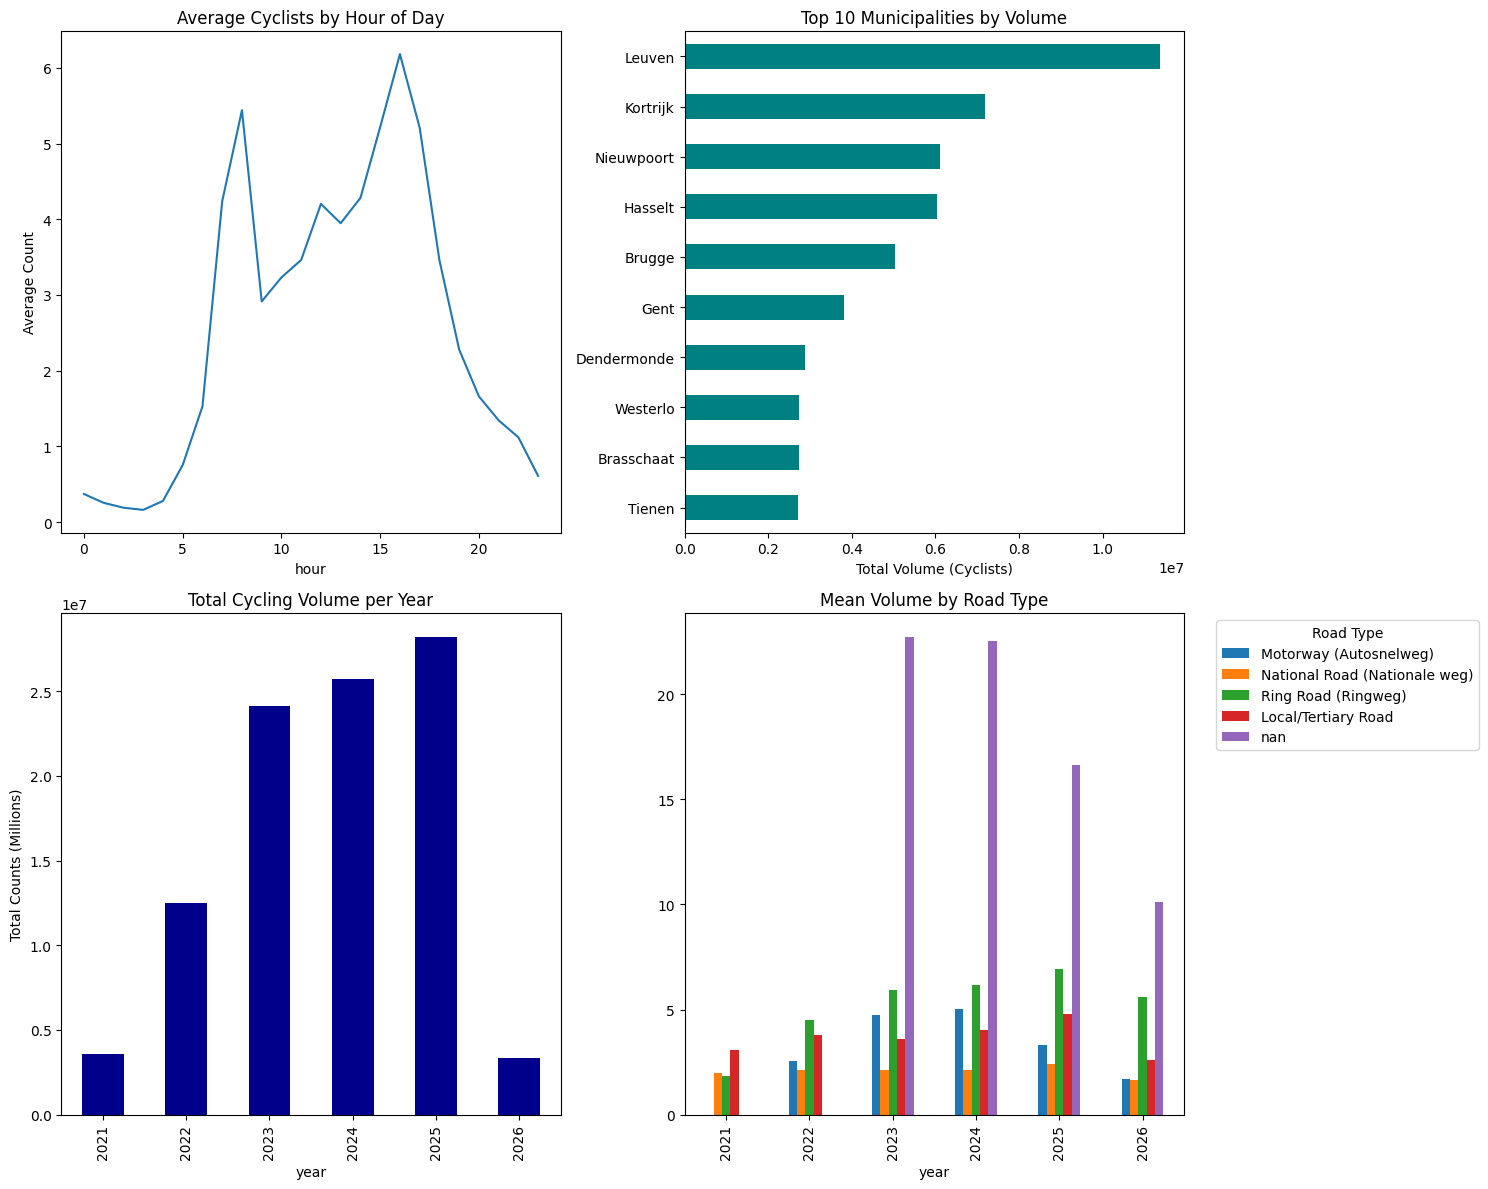

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

hourly_trend = df_cyclists.groupby('hour')['aantal'].mean()
hourly_trend.plot(kind='line', ax=axes[0, 0], title='Average Cyclists by Hour of Day')
axes[0, 0].set_ylabel('Average Count')

df_full = pd.merge(df_cyclists, df_sites[['site_id', 'gemeente']],  on='site_id',  how='left')
top_municipalities = ( df_full.groupby('gemeente')['aantal'].sum().sort_values(ascending=True).tail(10))   
top_municipalities.plot(kind='barh', ax=axes[0, 1], color='teal', title='Top 10 Municipalities by Volume')
axes[0, 1].set_xlabel('Total Volume (Cyclists)')
axes[0, 1].set_ylabel('') 

yearly_growth = df_cyclists.groupby('year')['aantal'].sum()
yearly_growth.plot(kind='bar', ax=axes[1, 0], color='darkblue', title='Total Cycling Volume per Year')
axes[1, 0].set_ylabel('Total Counts (Millions)')

road_labels = {
    'A': 'Motorway (Autosnelweg)',
    'N': 'National Road (Nationale weg)',
    'R': 'Ring Road (Ringweg)',
    'T': 'Local/Tertiary Road'
}

df_road_trends = df_cyclists.merge(df_sites[['site_id', 'road_type']], on='site_id')
road_plot_data = df_road_trends.groupby(['year', 'road_type'])['aantal'].mean().unstack()

road_plot_data = road_plot_data.rename(columns=road_labels)

road_plot_data.plot(kind='bar', ax=axes[1, 1], title='Mean Volume by Road Type')
axes[1, 1].legend(title='Road Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('1.jpg', dpi=300, bbox_inches='tight')
plt.show()


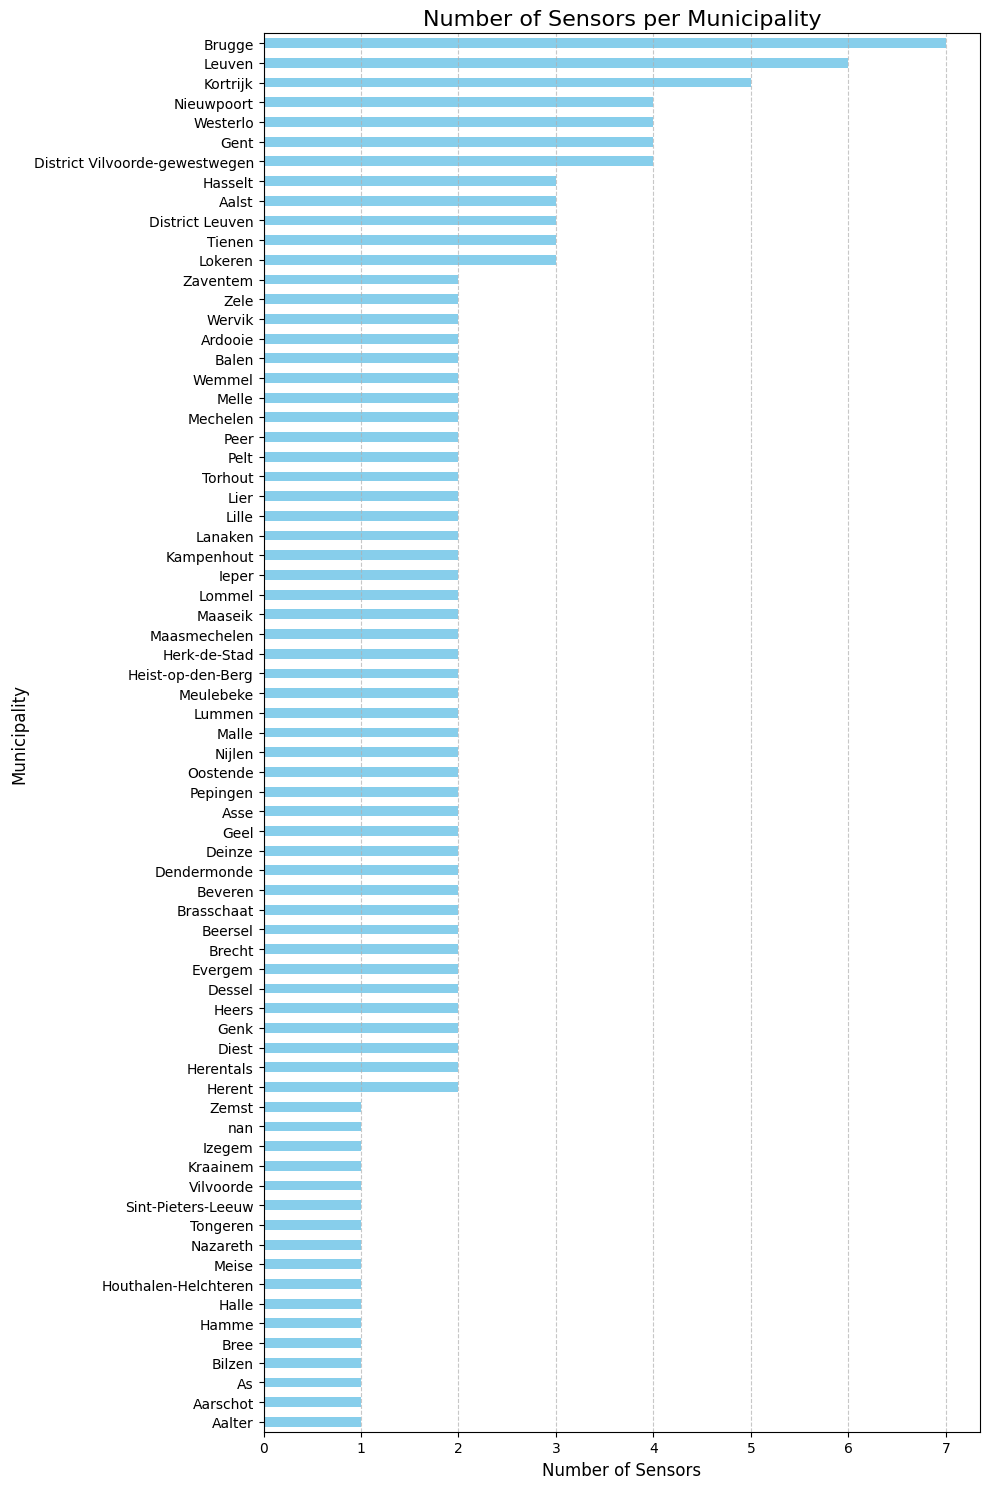

In [137]:
sensor_counts = df_sites.groupby('gemeente')['site_id'].nunique().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 15))

sensor_counts.plot(kind='barh', color='skyblue', ax=ax)

ax.set_title('Number of Sensors per Municipality', fontsize=16)
ax.set_xlabel('Number of Sensors', fontsize=12)
ax.set_ylabel('Municipality', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('2.jpg', dpi=300, bbox_inches='tight')
plt.show()


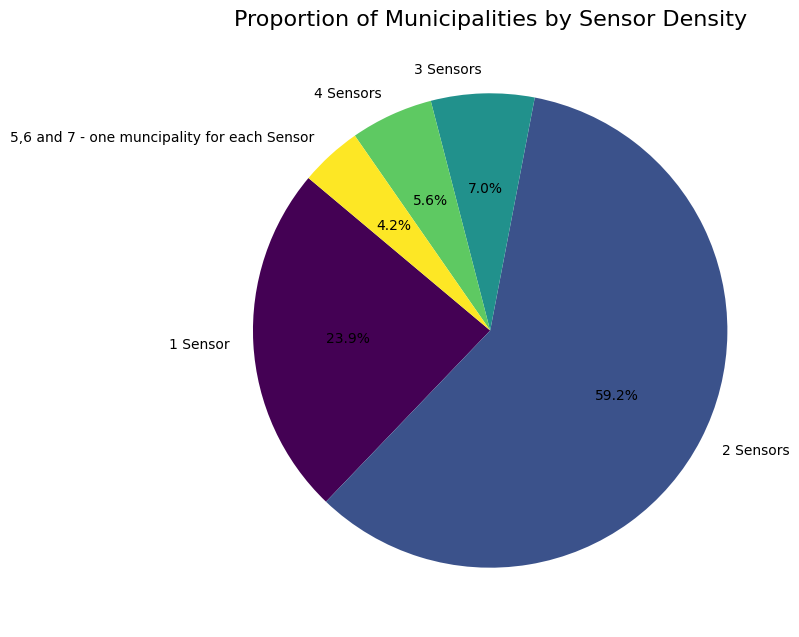

In [138]:
sensor_counts = df_sites.groupby('gemeente')['site_id'].nunique()
density_distribution = sensor_counts.value_counts().sort_index()

if all(x in density_distribution.index for x in [5, 6, 7]):
    grouped_value = density_distribution.loc[[5, 6, 7]].sum()
    density_distribution = density_distribution.drop([5, 6, 7])
    density_distribution['5,6 and 7 - one muncipality for each'] = grouped_value

labels = [f"{idx} Sensor{'s' if (isinstance(idx, int) and idx != 1) else ''}" 
          for idx in density_distribution.index]

fig, ax = plt.subplots(figsize=(8, 8))

num_colors = len(density_distribution)
colors = plt.cm.viridis(np.linspace(0, 1, num_colors))

density_distribution.plot(
    kind='pie', 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, # Corrected parameter
    shadow=False, 
    ax=ax
)

ax.set_title('Proportion of Municipalities by Sensor Density', fontsize=16)
ax.set_ylabel('') 

plt.tight_layout()
plt.savefig('3.jpg', dpi=300, bbox_inches='tight')
plt.show()


Can include the findings here on the report!

Auxiliary data

1. Weather-Data

In [13]:
def apply_master_weather_mapping(df_sites): #picked these up from online repos
    weather_mapping = {
        #Antwerp (06450)
        'Brasschaat': '06450', 'Brecht': '06450', 'Nijlen': '06450', 
        'Lier': '06450', 'Mechelen': '06450', 'District Vilvoorde-gewestwegen': '06450', 
        'Westerlo': '06450', 'Herentals': '06450', 'Geel': '06450', 'Malle': '06450', 
        'Lille': '06450', 'Dessel': '06450', 'Heist-op-den-Berg': '06450',

        # Ghent & East Flanders (06434)
        'Evergem': '06434', 'Gent': '06434', 'Deinze': '06434', 
        'Nazareth': '06434', 'Aalter': '06434', 'Melle': '06434', 
        'Zele': '06434', 'Dendermonde': '06434', 'Beveren': '06434', 
        'Hamme': '06434', 'Lokeren': '06434', 'Aalst': '06434',

        # Brussels & Leuven (06451)
        'Kraainem': '06451', 'Zaventem': '06451', 'Meise': '06451', 
        'Wemmel': '06451', 'Beersel': '06451', 'Asse': '06451', 
        'Vilvoorde': '06451', 'Halle': '06451', 'Sint-Pieters-Leeuw': '06451',
        'Pepingen': '06451', 'Zemst': '06451', 'Leuven': '06451', 
        'Tienen': '06451', 'Aarschot': '06451', 'Diest': '06451', 
        'Herent': '06451', 'Kampenhout': '06451', 'District Leuven': '06451',

        # Limburg (06479)
        'Genk': '06479', 'Bilzen': '06479', 'Bree': '06479', 
        'Tongeren': '06479', 'Lanaken': '06479', 'Lommel': '06479', 
        'Peer': '06479', 'Maasmechelen': '06479', 'Maaseik': '06479', 
        'Pelt': '06479', 'As': '06479', 'Hasselt': '06479', 
        'Houthalen-Helchteren': '06479', 'Heers': '06479',
        'Herk-de-Stad': '06479', 'Lummen': '06479', 'Balen': '06479',

        # West Flanders Coast (06407)
        'Oostende': '06407', 'Nieuwpoort': '06407',

        # West Flanders Inland (06456)
        'Kortrijk': '06456', 'Torhout': '06456', 
        'Ieper': '06456', 'Izegem': '06456', 'Ardooie': '06456',
        'Meulebeke': '06456', 'Wervik': '06456'
    }

    df_sites['weather_station_id'] = df_sites['gemeente'].map(weather_mapping)

    # setting proxy as the main hub in brussels
    df_sites['weather_station_id'] = df_sites['weather_station_id'].fillna('06451')

    unmapped_count = df_sites['weather_station_id'].isna().sum()
    print(f"Total Sites: {len(df_sites)}")
    print(f"Central Proxy (06451) applied to {unmapped_count} unknown sites.")
    
    return df_sites

df_sites = apply_master_weather_mapping(df_sites)

Total Sites: 150
Central Proxy (06451) applied to 0 unknown sites.


In [14]:
def fetch_weather_api(station_id, start, end):
    url = f"https://bulk.meteostat.net/v2/hourly/{station_id}.csv.gz"
    try:
        df = pd.read_csv(url, compression='gzip', header=None,
                         names=['date', 'hour', 'temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'coco'])
        
        df['time'] = pd.to_datetime(df['date'] + ' ' + df['hour'].astype(str).str.zfill(2) + ':00:00')
        
        # Localize to Belgium Time
        df['time'] = df['time'].dt.tz_localize('UTC').dt.tz_convert('Europe/Brussels').dt.tz_localize(None)
        
        df = df[(df['time'] >= start) & (df['time'] <= end)]
        
        df['prcp'] = df['prcp'].fillna(0)
        df['snow'] = df['snow'].fillna(0)
        df['temp'] = df['temp'].interpolate(method='linear') # Fill temp gaps
        
        df['weather_station_id'] = station_id
        return df[['time', 'temp', 'prcp', 'wspd', 'snow', 'weather_station_id']]
    
    except Exception as e:
        print(f"Error @ station {station_id}: {e}")
        return None

weather_list = []
unique_station = df_sites['weather_station_id'].unique().tolist()
for s_id in unique_station:
    data = fetch_weather_api(s_id, '2021-01-01', '2025-12-31')
    if data is not None:
        weather_list.append(data)

master_weather_df_hourly = pd.concat(weather_list, ignore_index=True)
weather_pl = pl.from_pandas(master_weather_df_hourly)

In [15]:
weather_pl.head(5)

time,temp,prcp,wspd,snow,weather_station_id
datetime[ns],f64,f64,f64,f64,str
2021-01-01 00:00:00,0.6,0.0,3.6,0.0,"""06450"""
2021-01-01 01:00:00,-0.2,0.0,0.0,0.0,"""06450"""
2021-01-01 02:00:00,1.5,0.0,3.6,0.0,"""06450"""
2021-01-01 03:00:00,2.2,0.0,0.0,0.0,"""06450"""
2021-01-01 04:00:00,1.5,0.0,3.6,0.0,"""06450"""


In [16]:
def prepare_for_polars(df):
    for col in df.columns:
        if df[col].dtype == "object" or df[col].dtype.name == "category":
            df[col] = df[col].astype(str)
        elif "Int" in df[col].dtype.name: 
            df[col] = df[col].fillna(0).astype(np.int64)
    return df

df_sites_fixed = prepare_for_polars(df_sites)
df_counts_fixed = prepare_for_polars(df_cyclists)

df_sites_pl = pl.from_pandas(df_sites_fixed)
df_counts_pl = pl.from_pandas(df_counts_fixed)

In [17]:
# convert to datetime or alias if already dt
df_counts_pl = df_counts_pl.with_columns([pl.col("van").cast(pl.Datetime).alias("timestamp")]).sort("timestamp")
master_weather_pl = weather_pl.with_columns([pl.col("time").cast(pl.Datetime).alias("weather_time")]).sort("weather_time")

#take only the cyclists from 2021 to end of 2025 cause the rest of the data available is mostly for that period
df_cyclists_filtered = (df_counts_pl.filter( 
        (pl.col("type") == "FIETSERS") & 
        (pl.col("timestamp") >= pl.datetime(2021, 1, 1)) & 
        (pl.col("timestamp") < pl.datetime(2026, 1, 1))))

df_combined = df_cyclists_filtered.join(df_sites_pl.select(["site_id", "weather_station_id"]), on="site_id", how="left")

df_combined = df_combined.with_columns(pl.col("timestamp").dt.cast_time_unit("us"))
master_weather_pl = master_weather_pl.with_columns(pl.col("weather_time").dt.cast_time_unit("us"))

# match each 15-min cyclist count to the weather immediately preceding it
final_df_pl = df_combined.join_asof(
    master_weather_pl,
    left_on="timestamp",
    right_on="weather_time",
    by="weather_station_id", 
    strategy="backward"
)

# Aggregate to Hourly
final_hourly_analysis = (
    final_df_pl
    .with_columns(pl.col("timestamp").dt.truncate("1h").alias("hour_bin"))
    .group_by(["site_id", "richting", "destination","hour_bin", "weather_station_id"])
    .agg([
        pl.col("aantal").fill_null(0).sum().alias("hourly_count"),
        pl.col("temp").mean().alias("temp"),
        pl.col("prcp").mean().alias("prcp"),
        pl.col("wspd").mean().alias("wspd"),
        pl.col("snow").mean().alias("snow_depth")
    ])
    .sort(["hour_bin", "site_id", "richting"])
)

final_hourly_analysis = final_hourly_analysis.with_columns([
    pl.col("hour_bin").dt.hour().alias("hour"),
    pl.col("hour_bin").dt.weekday().alias("day_of_week"),
    (pl.col("hour_bin").dt.weekday() >= 6).alias("is_weekend"),
    pl.col("hour_bin").dt.month().alias("month")
])

print(f"Total rows: {final_hourly_analysis.height}")

Total rows: 9225752


In [18]:
df_cleaned_weather = final_hourly_analysis.with_columns(
    pl.when(pl.col("site_id") == 1)
    .then(pl.lit("06450")) 
    .otherwise(pl.col("weather_station_id"))
    .alias("weather_station_id")
)

# Windowed Imputation
final_hourly_analysis = (
    df_cleaned_weather
    .sort(["weather_station_id", "hour_bin"]) 
    .with_columns([
        # Interpolate temperature 
        pl.col("temp").interpolate().over("weather_station_id"),
        
        # precipitation and snow zero-fills
        pl.col("prcp").fill_null(0),
        pl.col("snow").fill_null(0) if "snow" in df_cleaned_weather.columns else pl.lit(0),
        
        # Forward fill wind speed 
        pl.col("wspd").fill_null(strategy="forward").over("weather_station_id")
    ])
    .fill_null(0)
)

In [19]:
final_hourly_analysis.head(5)

site_id,richting,destination,hour_bin,weather_station_id,hourly_count,temp,prcp,wspd,snow_depth,hour,day_of_week,is_weekend,month,literal
i64,str,str,datetime[μs],str,f64,f64,f64,f64,f64,i8,i8,bool,i8,i32
15,"""OUT""","""Oostende""",2021-01-01 00:00:00,"""06407""",0.0,3.2,0.0,14.4,0.0,0,5,false,1,0
18,"""IN""","""Oostende 1 Fietsers rich. Oost…",2021-01-01 00:00:00,"""06407""",0.0,3.2,0.0,14.4,0.0,0,5,false,1,0
15,"""IN""","""Oostende 2 Fietser rich. Giste…",2021-01-01 00:00:00,"""06407""",1.0,3.2,0.0,14.4,0.0,0,5,false,1,0
18,"""OUT""","""Oostende 1 Fietsers rich. Gist…",2021-01-01 00:00:00,"""06407""",0.0,3.2,0.0,14.4,0.0,0,5,false,1,0
15,"""IN""","""Oostende 2 Fietser rich. Giste…",2021-01-01 01:00:00,"""06407""",0.0,3.7,0.0,14.4,0.0,1,5,false,1,0


In [20]:
final_hourly_analysis.write_csv('weather_fin.csv')

Aggregate into Provinces

In [21]:
province_map = {
    # Antwerpen
    "Balen": "Antwerpen", "Brasschaat": "Antwerpen", "Brecht": "Antwerpen", 
    "Dessel": "Antwerpen", "Geel": "Antwerpen", "Heist-op-den-Berg": "Antwerpen", 
    "Herentals": "Antwerpen", "Lier": "Antwerpen", "Lille": "Antwerpen", 
    "Malle": "Antwerpen", "Mechelen": "Antwerpen", "Nijlen": "Antwerpen", 
    "Westerlo": "Antwerpen",

    # Oost-Vlaanderen
    "Aalst": "Oost-Vlaanderen", "Aalter": "Oost-Vlaanderen", "Beveren": "Oost-Vlaanderen", 
    "Deinze": "Oost-Vlaanderen", "Dendermonde": "Oost-Vlaanderen", "Evergem": "Oost-Vlaanderen", 
    "Gent": "Oost-Vlaanderen", "Hamme": "Oost-Vlaanderen", "Lokeren": "Oost-Vlaanderen", 
    "Melle": "Oost-Vlaanderen", "Nazareth": "Oost-Vlaanderen", "Zele": "Oost-Vlaanderen",

    # Vlaams-Brabant
    "Aarschot": "Vlaams-Brabant", "Asse": "Vlaams-Brabant", "Beersel": "Vlaams-Brabant", 
    "Diest": "Vlaams-Brabant", "District Leuven": "Vlaams-Brabant", "District Vilvoorde-gewestwegen": "Vlaams-Brabant", 
    "Halle": "Vlaams-Brabant", "Herent": "Vlaams-Brabant", "Kampenhout": "Vlaams-Brabant", 
    "Kraainem": "Vlaams-Brabant", "Leuven": "Vlaams-Brabant", "Meise": "Vlaams-Brabant", 
    "Pepingen": "Vlaams-Brabant", "Sint-Pieters-Leeuw": "Vlaams-Brabant", "Tienen": "Vlaams-Brabant", 
    "Vilvoorde": "Vlaams-Brabant", "Wemmel": "Vlaams-Brabant", "Zaventem": "Vlaams-Brabant", 
    "Zemst": "Vlaams-Brabant",

    # West-Vlaanderen
    "Ardooie": "West-Vlaanderen", "Brugge": "West-Vlaanderen", "Ieper": "West-Vlaanderen", 
    "Izegem": "West-Vlaanderen", "Kortrijk": "West-Vlaanderen", "Meulebeke": "West-Vlaanderen", 
    "Nieuwpoort": "West-Vlaanderen", "Oostende": "West-Vlaanderen", "Torhout": "West-Vlaanderen", 
    "Wervik": "West-Vlaanderen",

    # Limburg
    "As": "Limburg", "Bilzen": "Limburg", "Bree": "Limburg", "Genk": "Limburg", 
    "Hasselt": "Limburg", "Heers": "Limburg", "Herk-de-Stad": "Limburg", 
    "Houthalen-Helchteren": "Limburg", "Lanaken": "Limburg", "Lommel": "Limburg", 
    "Lummen": "Limburg", "Maaseik": "Limburg", "Maasmechelen": "Limburg", 
    "Peer": "Limburg", "Pelt": "Limburg", "Tongeren": "Limburg"
}

df_sites_mapped = df_sites_pl.with_columns([
    pl.col("site_id").cast(pl.Int32)
]).with_columns([
    pl.when(pl.col("gemeente").is_in(list(province_map.keys())))
    .then(pl.col("gemeente").replace(province_map))
    
    .when(pl.col("site_id") == 1)
    .then(pl.lit("Antwerpen"))
    
    # ID block fallback
    .when((pl.col("site_id") >= 100) & (pl.col("site_id") <= 199)).then(pl.lit("Oost-Vlaanderen"))
    .when((pl.col("site_id") >= 300) & (pl.col("site_id") <= 399)).then(pl.lit("Vlaams-Brabant"))
    .when((pl.col("site_id") >= 700) & (pl.col("site_id") <= 799)).then(pl.lit("Limburg"))
    .when((pl.col("site_id") >= 200) & (pl.col("site_id") <= 299)).then(pl.lit("West-Vlaanderen"))
    
    .alias("res_region")
])

df_sites_mapped = df_sites_mapped.with_columns(
    pl.when(pl.col("gemeente").is_in(["Leuven", "District Leuven"]))
    .then(pl.lit("Leuven"))
    .otherwise(pl.col("res_region"))
    .alias("res_region")
)

Mark all sites on a map of Flanders

In [22]:
m_flanders = folium.Map(location=[51.0, 4.45], zoom_start=9, tiles="cartodbpositron")
marker_cluster = MarkerCluster().add_to(m_flanders)

def get_region_color(region):
    r = str(region)
    if r == 'Leuven': return 'green'
    if r == 'Antwerpen': return 'red'
    if r == 'Oost-Vlaanderen': return 'blue'
    if r == 'Vlaams-Brabant': return 'purple'
    if r == 'West-Vlaanderen': return 'cadetblue'
    if r == 'Limburg': return 'orange'
    return 'gray'

for row in df_sites_mapped.to_dicts():
    if row['lat'] and row['long']:
        region_name = row['res_region']
        
        popup_content = (
            f"<b>{row['naam']}</b><br>"
            f"<b>Site ID: {row['site_id']}</b><br>"  
            f"Mapped Region: {region_name}<br>"
            f"Municipality: {row['gemeente']}"
        )
        
        folium.CircleMarker(
            location=[row['lat'], row['long']],
            radius=7,
            popup=folium.Popup(popup_content, max_width=300), 
            color=get_region_color(region_name),
            fill=True,
            fill_opacity=0.8,
            weight=1
        ).add_to(marker_cluster)

m_flanders

Economic data - only till 2023 in this file tho

In [23]:
#yearly info!
df_fiscal = (
    pl.read_csv(
        "ext/fiscal.txt", 
        separator="|", 
        infer_schema_length=10000,
        null_values=["", "NA", "null"],
        ignore_errors=True
    )
    .filter((pl.col("CD_YEAR") >= 2019) & (pl.col("CD_YEAR") <= 2025))
    .with_columns([
        (pl.col("MS_TOT_NET_TAXABLE_INC").cast(pl.Float64) / 
         pl.col("MS_TOT_RESIDENTS").cast(pl.Float64)).alias("avg_income_per_capita"),
        
        (pl.col("MS_NBR_NET_PROF_INC").cast(pl.Float64) / 
         pl.col("MS_TOT_RESIDENTS").cast(pl.Float64)).alias("prof_earner_ratio"),
        
        pl.col("TX_MUNTY_DESCR_NL").alias("gemeente"),
        pl.col("CD_YEAR").alias("year")
    ])
    .select(["gemeente", "year", "avg_income_per_capita", "prof_earner_ratio"])
)

In [24]:
stats = df_fiscal.group_by("gemeente").agg([
    pl.len().alias("n"),
    pl.col("year").sum().alias("sum_x"),
    pl.col("year").pow(2).sum().alias("sum_xx"),
    pl.col("avg_income_per_capita").sum().alias("sum_y_inc"),
    (pl.col("year") * pl.col("avg_income_per_capita")).sum().alias("sum_xy_inc"),
    pl.col("prof_earner_ratio").sum().alias("sum_y_prof"),
    (pl.col("year") * pl.col("prof_earner_ratio")).sum().alias("sum_xy_prof")
])

# Slopes (m) and Intercepts (b) for both variables
stats = stats.with_columns([
    ((pl.col("n") * pl.col("sum_xy_inc") - pl.col("sum_x") * pl.col("sum_y_inc")) / 
     (pl.col("n") * pl.col("sum_xx") - pl.col("sum_x").pow(2))).alias("m_inc"),
    ((pl.col("n") * pl.col("sum_xy_prof") - pl.col("sum_x") * pl.col("sum_y_prof")) / 
     (pl.col("n") * pl.col("sum_xx") - pl.col("sum_x").pow(2))).alias("m_prof")
]).with_columns([
    ((pl.col("sum_y_inc") - pl.col("m_inc") * pl.col("sum_x")) / pl.col("n")).alias("b_inc"),
    ((pl.col("sum_y_prof") - pl.col("m_prof") * pl.col("sum_x")) / pl.col("n")).alias("b_prof")
])

#forecast 
future_years = pl.DataFrame({"year": [2024, 2025]}).with_columns(pl.col("year").cast(pl.Int64))
gemeentes = stats.select("gemeente").unique()
df_future = gemeentes.join(future_years, how="cross")

# y = mx + b
df_future = df_future.join(stats.select(["gemeente", "m_inc", "b_inc", "m_prof", "b_prof"]), on="gemeente")

df_future = df_future.with_columns([
    (pl.col("m_inc") * pl.col("year") + pl.col("b_inc")).alias("avg_income_per_capita"),
    (pl.col("m_prof") * pl.col("year") + pl.col("b_prof")).alias("prof_earner_ratio")
]).select(["gemeente", "year", "avg_income_per_capita", "prof_earner_ratio"])

df_fiscal_extended = pl.concat([
    df_fiscal.select(["gemeente", "year", "avg_income_per_capita", "prof_earner_ratio"]), 
    df_future
], how="vertical").sort(["gemeente", "year"])

In [25]:
df_fiscal_extended.head(10)

gemeente,year,avg_income_per_capita,prof_earner_ratio
str,i64,f64,f64
"""Aalst""",2019,20369.154809,0.57886
"""Aalst""",2020,20720.438307,0.571893
"""Aalst""",2021,21372.589598,0.576508
"""Aalst""",2022,22937.319664,0.590854
"""Aalst""",2023,24427.638637,0.591747
"""Aalst""",2024,25065.582907,0.595392
"""Aalst""",2025,26098.967808,0.599866
"""Aalter""",2019,21957.70297,0.571859
"""Aalter""",2020,22359.909538,0.566787


In [26]:
if not isinstance(df_sites_mapped, pl.DataFrame):
    df_sites_pl = pl.from_pandas(df_sites_mapped)
else:
    df_sites_pl = df_sites_mapped

df_sensors_metadata = df_sites_pl.unique(subset=["site_id"]).select([
    "site_id", "long", "lat", "gemeente", "datum_van", "weather_station_id","wegnr","road_type","res_region","naam"
])

years_df = pl.DataFrame({"year": [2021, 2022, 2023, 2024, 2025]}).with_columns(pl.col("year").cast(pl.Int64))

# site is cross-joined with every year (5 rows per site)
df_master = df_sensors_metadata.join(years_df, how="cross")

df_final = df_master.join(
    df_fiscal_extended.select(["gemeente", "year", "avg_income_per_capita", "prof_earner_ratio"]),
    on=["gemeente", "year"],
    how="left"
)

# calculate how old the infrastructure is @ that year
df_final = df_final.with_columns([
    (pl.col("year") - pl.col("datum_van").cast(pl.Date).dt.year()).alias("relative_sensor_age")
]).with_columns([
    # If the year is before installation, age = 0
    pl.when(pl.col("relative_sensor_age") < 0)
    .then(0)
    .otherwise(pl.col("relative_sensor_age"))
    .alias("relative_sensor_age")
])

In [27]:
# each munipality has data from 2019 to 2023 and for 24/25 it is extrapolated
df_final.filter(pl.col("gemeente") == "Brasschaat").sort(["site_id", "year"]).head(10)

site_id,long,lat,gemeente,datum_van,weather_station_id,wegnr,road_type,res_region,naam,year,avg_income_per_capita,prof_earner_ratio,relative_sensor_age
i32,f64,f64,str,str,str,str,str,str,str,i64,f64,f64,i64
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2021,24823.755821,0.56903,2
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2022,26355.062841,0.583176,3
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2023,28766.254128,0.585235,4
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2024,29216.653067,0.590991,5
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2025,30420.861128,0.59688,6
3,4.47222,51.27503,"""Brasschaat""","""2019-08-22""","""06450""","""N0010001""","""N""","""Antwerpen""","""Brasschaat 1""",2021,24823.755821,0.56903,2
3,4.47222,51.27503,"""Brasschaat""","""2019-08-22""","""06450""","""N0010001""","""N""","""Antwerpen""","""Brasschaat 1""",2022,26355.062841,0.583176,3
3,4.47222,51.27503,"""Brasschaat""","""2019-08-22""","""06450""","""N0010001""","""N""","""Antwerpen""","""Brasschaat 1""",2023,28766.254128,0.585235,4
3,4.47222,51.27503,"""Brasschaat""","""2019-08-22""","""06450""","""N0010001""","""N""","""Antwerpen""","""Brasschaat 1""",2024,29216.653067,0.590991,5


Population Data

In [28]:
def process_demographics(file_path, year):
    try:
        df = pd.read_csv(file_path, sep='|', low_memory=False, encoding='latin1')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, sep='|', low_memory=False, encoding='cp1252')

    df['TX_DESCR_NL'] = df['TX_DESCR_NL'].str.replace(r"\(.*\)", "", regex=True).str.strip()
    
    mapping = {
        "Beveren (Saint-Nicolas)": "Beveren"
    }
    df['TX_DESCR_NL'] = df['TX_DESCR_NL'].replace(mapping)

    df['CD_AGE'] = pd.to_numeric(df['CD_AGE'], errors='coerce')
    df['MS_POPULATION'] = pd.to_numeric(df['MS_POPULATION'], errors='coerce')
    
    agg_df = df.groupby('TX_DESCR_NL').apply(lambda x: pd.Series({
        'total_pop': x['MS_POPULATION'].sum(),
        'cnt_young_children': x[x['CD_AGE'] < 8]['MS_POPULATION'].sum(),
        'cnt_school_kids': x[(x['CD_AGE'] >= 8) & (x['CD_AGE'] < 18)]['MS_POPULATION'].sum(),
        'cnt_uni_students': x[(x['CD_AGE'] >= 18) & (x['CD_AGE'] < 26)]['MS_POPULATION'].sum(),
        'cnt_young_profs': x[(x['CD_AGE'] >= 26) & (x['CD_AGE'] < 40)]['MS_POPULATION'].sum(),
        'cnt_senior_profs': x[(x['CD_AGE'] >= 40) & (x['CD_AGE'] < 65)]['MS_POPULATION'].sum(),
        'cnt_seniors': x[x['CD_AGE'] >= 65]['MS_POPULATION'].sum(),
        'cnt_male': x[x['CD_SEX'] == 'M']['MS_POPULATION'].sum(),
        'cnt_female': x[x['CD_SEX'] == 'F']['MS_POPULATION'].sum(),
        'cnt_belgian': x[x['CD_NATLTY'] == 'BEL']['MS_POPULATION'].sum(),
        'cnt_foreign': x[x['CD_NATLTY'] != 'BEL']['MS_POPULATION'].sum(),
        'cnt_single': x[x['CD_CIV_STS'] == 1]['MS_POPULATION'].sum(),
        'cnt_married': x[x['CD_CIV_STS'] == 2]['MS_POPULATION'].sum(),
        'cnt_widowed': x[x['CD_CIV_STS'] == 3]['MS_POPULATION'].sum(),
        'cnt_divorced': x[x['CD_CIV_STS'] == 4]['MS_POPULATION'].sum()
    })).reset_index()

    cols_to_pct = [c for c in agg_df.columns if c.startswith('cnt_')]
    for col in cols_to_pct:
        pct_name = col.replace('cnt_', 'pct_')
        agg_df[pct_name] = agg_df[col] / agg_df['total_pop']
        
    agg_df['year'] = year
    return agg_df.rename(columns={'TX_DESCR_NL': 'gemeente'})
    
df_pop_2021 = process_demographics("ext/TF_SOC_POP_STRUCT_2021.txt", 2021)
df_pop_2022 = process_demographics("ext/TF_SOC_POP_STRUCT_2022.txt", 2022)
df_pop_2023 = process_demographics("ext/TF_SOC_POP_STRUCT_2023.txt", 2023)
df_pop_2024 = process_demographics("ext/TF_SOC_POP_STRUCT_2024.txt", 2024)
df_pop_2025 = process_demographics("ext/TF_SOC_POP_STRUCT_2025.txt", 2025)

In [29]:
df_pop_all_years = pd.concat([df_pop_2021, df_pop_2022, df_pop_2023, df_pop_2024, df_pop_2025], ignore_index=True)
df_pop_all_years = pl.from_pandas(df_pop_all_years)

In [30]:
print(df_pop_all_years.filter(pl.col("gemeente") == "Aalter")) #2021 to 2025

shape: (5, 31)
┌──────────┬───────────┬────────────────────┬─────────────────┬───┬─────────────┬─────────────┬──────────────┬──────┐
│ gemeente ┆ total_pop ┆ cnt_young_children ┆ cnt_school_kids ┆ … ┆ pct_married ┆ pct_widowed ┆ pct_divorced ┆ year │
│ ---      ┆ ---       ┆ ---                ┆ ---             ┆   ┆ ---         ┆ ---         ┆ ---          ┆ ---  │
│ str      ┆ i64       ┆ i64                ┆ i64             ┆   ┆ f64         ┆ f64         ┆ f64          ┆ i64  │
╞══════════╪═══════════╪════════════════════╪═════════════════╪═══╪═════════════╪═════════════╪══════════════╪══════╡
│ Aalter   ┆ 29242     ┆ 2102               ┆ 3197            ┆ … ┆ 0.421962    ┆ 0.058375    ┆ 0.082894     ┆ 2021 │
│ Aalter   ┆ 29340     ┆ 2138               ┆ 3194            ┆ … ┆ 0.417246    ┆ 0.059032    ┆ 0.084288     ┆ 2022 │
│ Aalter   ┆ 29529     ┆ 2150               ┆ 3171            ┆ … ┆ 0.41146     ┆ 0.058925    ┆ 0.086288     ┆ 2023 │
│ Aalter   ┆ 29787     ┆ 2166            

In [31]:
df_pop_2025[df_pop_2025["gemeente"] == "Meulebeke"]

,gemeente,total_pop,cnt_young_children,cnt_school_kids,cnt_uni_students,cnt_young_profs,cnt_senior_profs,cnt_seniors,cnt_male,cnt_female,...,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,year


In [32]:
targets = ["Beveren", "Bilzen", "Melle", "Meulebeke", "Nazareth", "Tongeren"]

latest_records = (
    df_pop_all_years.filter(pl.col("gemeente").is_in(targets))
    .sort("year")
    .group_by("gemeente")
    .last()
)

extrapolated_2025 = (
    latest_records.with_columns([
        pl.lit(2025).cast(pl.Int64).alias("year"),
        
        (pl.col("total_pop") * 1.01).cast(pl.Int64).alias("total_pop")
    ])
)

df_pop_final = pl.concat([df_pop_all_years, extrapolated_2025])

In [33]:
df_pop_final
print(df_pop_final.filter(pl.col("gemeente") == "Aalter")) #2021 to 2025
print(df_pop_final.filter(pl.col("gemeente") == "Melle")) #2021 to 2025

shape: (5, 31)
┌──────────┬───────────┬────────────────────┬─────────────────┬───┬─────────────┬─────────────┬──────────────┬──────┐
│ gemeente ┆ total_pop ┆ cnt_young_children ┆ cnt_school_kids ┆ … ┆ pct_married ┆ pct_widowed ┆ pct_divorced ┆ year │
│ ---      ┆ ---       ┆ ---                ┆ ---             ┆   ┆ ---         ┆ ---         ┆ ---          ┆ ---  │
│ str      ┆ i64       ┆ i64                ┆ i64             ┆   ┆ f64         ┆ f64         ┆ f64          ┆ i64  │
╞══════════╪═══════════╪════════════════════╪═════════════════╪═══╪═════════════╪═════════════╪══════════════╪══════╡
│ Aalter   ┆ 29242     ┆ 2102               ┆ 3197            ┆ … ┆ 0.421962    ┆ 0.058375    ┆ 0.082894     ┆ 2021 │
│ Aalter   ┆ 29340     ┆ 2138               ┆ 3194            ┆ … ┆ 0.417246    ┆ 0.059032    ┆ 0.084288     ┆ 2022 │
│ Aalter   ┆ 29529     ┆ 2150               ┆ 3171            ┆ … ┆ 0.41146     ┆ 0.058925    ┆ 0.086288     ┆ 2023 │
│ Aalter   ┆ 29787     ┆ 2166            

In [34]:
df_master = df_final.join( df_pop_final,on=["gemeente", "year"],how="inner")

In [35]:
df_master.filter(pl.col("gemeente") == "Brasschaat").sort(["site_id", "year"]).head(10)

site_id,long,lat,gemeente,datum_van,weather_station_id,wegnr,road_type,res_region,naam,year,avg_income_per_capita,prof_earner_ratio,relative_sensor_age,total_pop,cnt_young_children,cnt_school_kids,cnt_uni_students,cnt_young_profs,cnt_senior_profs,cnt_seniors,cnt_male,cnt_female,cnt_belgian,cnt_foreign,cnt_single,cnt_married,cnt_widowed,cnt_divorced,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced
i32,f64,f64,str,str,str,str,str,str,str,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2021,24823.755821,0.56903,2,38211,2778,4123,3261,5508,12970,9571,18328,19883,34523,3688,16612,15538,2365,3696,0.072702,0.107901,0.085342,0.144147,0.339431,0.250478,0.479652,0.520348,0.903483,0.096517,0.434744,0.406637,0.061893,0.096726
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2022,26355.062841,0.583176,3,38237,2814,4109,3196,5571,12835,9712,18320,19917,34574,3663,16776,15347,2368,3746,0.073594,0.107461,0.083584,0.145697,0.33567,0.253995,0.479117,0.520883,0.904203,0.095797,0.438737,0.401365,0.06193,0.097968
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2023,28766.254128,0.585235,4,38575,2822,4185,3174,5634,12804,9956,18444,20131,34632,3943,17148,15351,2339,3737,0.073156,0.10849,0.082281,0.146053,0.331925,0.258095,0.478134,0.521866,0.897784,0.102216,0.444537,0.397952,0.060635,0.096876
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2024,29216.653067,0.590991,5,38470,2722,4202,3138,5542,12711,10155,18386,20084,34516,3954,17045,15367,2311,3747,0.070756,0.109228,0.08157,0.14406,0.330413,0.263972,0.477931,0.522069,0.897219,0.102781,0.443073,0.399454,0.060073,0.097401
2,4.47169,51.27512,"""Brasschaat""","""2019-08-22""","""06450""","""N0010002""","""N""","""Antwerpen""","""Brasschaat 2""",2025,30420.861128,0.59688,6,38416,2672,4205,3147,5439,12640,10313,18389,20027,34528,3888,17116,15223,2322,3755,0.069554,0.10946,0.081919,0.141582,0.32903,0.268456,0.478681,0.521319,0.898792,0.101208,0.445544,0.396267,0.060444,0.097746
3,4.47222,51.27503,"""Brasschaat""","""2019-08-22""","""06450""","""N0010001""","""N""","""Antwerpen""","""Brasschaat 1""",2021,24823.755821,0.56903,2,38211,2778,4123,3261,5508,12970,9571,18328,19883,34523,3688,16612,15538,2365,3696,0.072702,0.107901,0.085342,0.144147,0.339431,0.250478,0.479652,0.520348,0.903483,0.096517,0.434744,0.406637,0.061893,0.096726
3,4.47222,51.27503,"""Brasschaat""","""2019-08-22""","""06450""","""N0010001""","""N""","""Antwerpen""","""Brasschaat 1""",2022,26355.062841,0.583176,3,38237,2814,4109,3196,5571,12835,9712,18320,19917,34574,3663,16776,15347,2368,3746,0.073594,0.107461,0.083584,0.145697,0.33567,0.253995,0.479117,0.520883,0.904203,0.095797,0.438737,0.401365,0.06193,0.097968
3,4.47222,51.27503,"""Brasschaat""","""2019-08-22""","""06450""","""N0010001""","""N""","""Antwerpen""","""Brasschaat 1""",2023,28766.254128,0.585235,4,38575,2822,4185,3174,5634,12804,9956,18444,20131,34632,3943,17148,15351,2339,3737,0.073156,0.10849,0.082281,0.146053,0.331925,0.258095,0.478134,0.521866,0.897784,0.102216,0.444537,0.397952,0.060635,0.096876
3,4.47222,51.27503,"""Brasschaat""","""2019-08-22""","""06450""","""N0010001""","""N""","""Antwerpen""","""Brasschaat 1""",2024,29216.653067,0.590991,5,38470,2722,4202,3138,5542,12711,10155,18386,20084,34516,3954,17045,15367,2311,3747,0.070756,0.109228,0.08157,0.14406,0.330413,0.263972,0.477931,0.522069,0.897219,0.102781,0.443073,0.399454,0.060073,0.097401


Employment data

In [37]:
def process_lfs_employment(file_path, target_year):
    df = pd.read_csv(file_path, sep='|', encoding='latin1')
    
    df_rate = df[
        (df['CD_PROPERTY'] == 'MS_EMPMT_RATE') & 
        (df['CD_YEAR'] == target_year) 
    ]
    
    lfs_summary = df_rate.groupby(['TX_NUTS_LVL2_DESCR_NL']).agg({
        'MS_VALUE': 'mean' 
    }).reset_index()
    
    lfs_summary['year'] = target_year
    return lfs_summary

lfs_dfs = []
for y in range(2021, 2026):
    path = f"ext/TF_HVD_LFS_EMPLOYMENT.csv" 
    lfs_dfs.append(process_lfs_employment(path, y))

df_lfs_pandas = pd.concat(lfs_dfs, ignore_index=True)

df_lfs_pandas = df_lfs_pandas.rename(columns={
    "TX_NUTS_LVL2_DESCR_NL": "province_name",
    "MS_VALUE": "avg_employment_rate"
})

df_lfs_pl = pl.from_pandas(df_lfs_pandas)

df_lfs_pl = df_lfs_pl.with_columns(pl.col("year").cast(pl.Int32))

In [38]:
df_lfs_yearly = (
    df_lfs_pl
    .group_by(["province_name", "year"])
    .agg([
        pl.col("avg_employment_rate").mean().alias("avg_employment_rate")
    ])
    .sort(["province_name", "year"])
)

In [39]:
province_map = {
    "Antwerpen (Province)": "Provincie Antwerpen",
    "Oost-Vlaanderen": "Provincie Oost-Vlaanderen",
    "Vlaams-Brabant": "Provincie Vlaams-Brabant",
    "West-Vlaanderen": "Provincie West-Vlaanderen",
    "Limburg": "Provincie Limburg",
    "Leuven": "Provincie Vlaams-Brabant"
}

df_final = (
    df_master
    .with_columns([
        pl.col("year").cast(pl.Int32),
        pl.col("res_region").replace(province_map, default=pl.col("res_region")).alias("join_province")
    ])
    .join(
        df_lfs_yearly,
        left_on=["join_province", "year"],
        right_on=["province_name", "year"],
        how="left"
    )
    .with_columns(
        pl.col("avg_employment_rate").fill_null(pl.col("avg_employment_rate").median())
    )
    .drop("join_province")
)


(Deprecated in version 1.0.0)


In [40]:
df_final.filter(pl.col("gemeente") == "Aarschot").unique().sort("year").head(10)

site_id,long,lat,gemeente,datum_van,weather_station_id,wegnr,road_type,res_region,naam,year,avg_income_per_capita,prof_earner_ratio,relative_sensor_age,total_pop,cnt_young_children,cnt_school_kids,cnt_uni_students,cnt_young_profs,cnt_senior_profs,cnt_seniors,cnt_male,cnt_female,cnt_belgian,cnt_foreign,cnt_single,cnt_married,cnt_widowed,cnt_divorced,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,avg_employment_rate
i32,f64,f64,str,str,str,str,str,str,str,i32,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
87,4.81259,50.99084,"""Aarschot""","""2022-07-16""","""06451""","""R0250002""","""R""","""Vlaams-Brabant""","""Aarschot""",2021,23051.526778,0.601294,0,30281,2157,2843,2398,5351,10652,6880,14840,15441,28824,1457,13647,11642,2018,2974,0.071233,0.093887,0.079192,0.176711,0.351772,0.227205,0.490076,0.509924,0.951884,0.048116,0.450679,0.384466,0.066642,0.098213,0.700013
87,4.81259,50.99084,"""Aarschot""","""2022-07-16""","""06451""","""R0250002""","""R""","""Vlaams-Brabant""","""Aarschot""",2022,24892.674499,0.614572,0,30594,2171,2910,2400,5395,10666,7052,14995,15599,29015,1579,13982,11531,2014,3067,0.070962,0.095117,0.078447,0.176342,0.34863,0.230503,0.490129,0.509871,0.948389,0.051611,0.457018,0.376904,0.06583,0.100248,0.695224
87,4.81259,50.99084,"""Aarschot""","""2022-07-16""","""06451""","""R0250002""","""R""","""Vlaams-Brabant""","""Aarschot""",2023,26621.882047,0.612885,1,30854,2195,2960,2391,5417,10682,7209,15121,15733,29163,1691,14320,11501,1979,3054,0.071142,0.095936,0.077494,0.175569,0.346211,0.233649,0.490082,0.509918,0.945193,0.054807,0.464121,0.372756,0.064141,0.098982,0.695788
87,4.81259,50.99084,"""Aarschot""","""2022-07-16""","""06451""","""R0250002""","""R""","""Vlaams-Brabant""","""Aarschot""",2024,27422.674419,0.618884,2,31138,2152,3030,2393,5494,10714,7355,15261,15877,29340,1798,14575,11498,1966,3099,0.069112,0.097309,0.076851,0.17644,0.344081,0.236207,0.490109,0.509891,0.942257,0.057743,0.468078,0.369259,0.063138,0.099525,0.706726
87,4.81259,50.99084,"""Aarschot""","""2022-07-16""","""06451""","""R0250002""","""R""","""Vlaams-Brabant""","""Aarschot""",2025,28650.12192,0.62364,3,31514,2144,3076,2435,5590,10718,7551,15447,16067,29527,1987,14863,11546,1988,3117,0.068033,0.097607,0.077267,0.177381,0.340103,0.239608,0.490163,0.509837,0.936949,0.063051,0.471632,0.366377,0.063083,0.098908,0.724252


In [41]:
gemeentes_to_check = ["Beveren", "Bilzen", "Melle", "Meulebeke", "Nazareth", "Tongeren"]

existing_in_2025 = (
    df_final.filter(pl.col("year") == 2025)
    .select(pl.col("gemeente").unique())
    .to_series()
    .to_list()
)

for gemeente in gemeentes_to_check:
    exists = gemeente in existing_in_2025
    print(f"{gemeente} exists for 2025: {exists}")

Beveren exists for 2025: True
Bilzen exists for 2025: True
Melle exists for 2025: True
Meulebeke exists for 2025: True
Nazareth exists for 2025: True
Tongeren exists for 2025: True


In [42]:
df_final.write_csv('sites_fin.csv')

site_id / site_nr: Unique identifiers for the physical counting equipment                                                                             long / lat: Geographic coordinates (Longitude/Latitude) for mapping.
naam: The descriptive name of the sensor location.
wegnr: The specific road number (e.g., N044 for a regional road).
district: administrative road district.
gemeente: municipality where the sensor is located.
datum_van: original installation/activation date of the sensor.
road_type: N for regional road, R for ring road, T for local/territorial
weather_station_id: ID of the nearest station providing the weather context for this site.
res_region: geographic region used for provincial-level mapping.
sensor_age_years: A calculation of how long the sensor has been operational relative to the study date.

year: The specific year this snapshot of data represents (important for the longitudinal 2021–2025 analysis).

avg_income_per_capita: The average net taxable income per resident in that municipality.
prof_earner_ratio: The percentage of the population that reports professional/business income (a proxy for the "white-collar" or "entrepreneurial" density of the area).

total_pop: Total inhabitants.
cnt_young_children (under 8): Future cyclists/dependents.
cnt_school_kids (8-18): Primary users of "School Corridors."
cnt_uni_students (18-26): High-density cycling group, often weather-resilient.
cnt_young_profs (26-40): Active commuters.
cnt_senior_profs (40-65): Experienced commuters, likely the highest income earners.
cnt_seniors (65+): Leisure cyclists.
cnt_male / cnt_female: Gender split.
cnt_belgian / cnt_foreign: Nationality split (measures international/expat influence).
cnt_single / married / widowed / divorced: Social structure indicators.

pct_young_children / pct_school_kids / etc.: The share of the total population belonging to each age bracket.
pct_male / pct_female: Gender balance.
pct_belgian / pct_foreign: Diversity index.
pct_single / married / widowed / divorced: Household composition. (e.g., high pct_single often correlates with high urban mobility).

avg_employment_rate: The average employment rate for the province that yea

Accident data

In [191]:
df_final=pl.read_csv('curated/sites_fin.csv')

In [192]:
final_hourly_analysis=pl.read_csv('curated/weather_fin.csv')

In [45]:
def extract_raw_accidents(file_path):
    return (
        pl.read_csv(
            file_path, 
            separator="|", 
            encoding="utf-8-sig", 
            infer_schema_length=20000,
            schema_overrides={"DT_TIME": pl.String, "CD_ROAD_USR_TYPE1": pl.String, "CD_ROAD_USR_TYPE2": pl.String} 
        )
        .with_columns([
            pl.col("DT_YEAR_COLLISION").cast(pl.Int64).alias("year"),
            pl.col("DT_TIME").str.slice(0, 2).cast(pl.Int32).alias("collision_hour"),
            pl.col("MS_X_COORD").str.strip_chars().str.replace(",", ".").cast(pl.Float64, strict=False).alias("x_lambert_acc"),
            pl.col("MS_Y_COORD").str.strip_chars().str.replace(",", ".").cast(pl.Float64, strict=False).alias("y_lambert_acc"),
        ])
        .filter(
            # Keep all traffic rows within these years
            pl.col("year").is_between(2021, 2025)
        )
        .with_columns([
            # bicycle involvement alone
            ((pl.col("TX_ROAD_USR_TYPE1_NL").str.to_lowercase() == "fiets") | 
             (pl.col("TX_ROAD_USR_TYPE2_NL").str.to_lowercase() == "fiets")).alias("is_bike_accident")
        ])
        .with_columns([
            # only if a bicycle is involved, calculate the split 
           pl.when(
                (pl.col("is_bike_accident") == True) & 
                pl.col("CD_CLASS_ACCIDENTS").is_in([1, 2, 3])
            ).then(1).otherwise(0).alias("is_severe"),
            
           pl.when(
                (pl.col("is_bike_accident") == True) & 
                (pl.col("TX_ROAD_USR_TYPE1_NL").str.to_lowercase().is_in(["personenauto", "vrachtwagen", "lichte vrachtauto", "autobus / autocar"]) |
                 pl.col("TX_ROAD_USR_TYPE2_NL").str.to_lowercase().is_in(["personenauto", "vrachtwagen", "lichte vrachtauto", "autobus / autocar"]))
            ).then(1).otherwise(0).alias("is_car_conflict"),
            
            pl.when((pl.col("is_bike_accident") == True) & (pl.col("TX_ROAD_CONDITION_NL").str.to_lowercase() != "droog"))
            .then(1).otherwise(0).alias("is_slick_road"),
              
            pl.when((pl.col("is_bike_accident") == True) & pl.col("CD_LIGHT_CONDITION").cast(pl.String).is_in(["2", "3"]))
            .then(1).otherwise(0).alias("is_dark"),
              
            pl.when((pl.col("is_bike_accident") == True) & (pl.col("TX_CROSSWAY_NL").str.to_lowercase() == "op kruispunt"))
            .then(1).otherwise(0).alias("is_intersection"),
              
            pl.when((pl.col("is_bike_accident") == True) & pl.col("collision_hour").is_in([7, 8, 15, 16]))
            .then(1).otherwise(0).alias("is_school_peak")
        ])
    )

df_accidents_raw = extract_raw_accidents("ext/OPENDATA_MAP_2017-2024.txt")

Lambert system proximity calculation

In [46]:
def project_sensors_to_lambert(df_sensors):
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:31370", always_xy=True)
    x_coords, y_coords = transformer.transform(
        df_sensors["long"].to_numpy(), 
        df_sensors["lat"].to_numpy()
    )
    return df_sensors.with_columns([
        pl.Series("sensor_x_lambert", x_coords),
        pl.Series("sensor_y_lambert", y_coords)
    ])

def filter_accidents_by_proximity(df_acc, df_sensors_lambert, radius=250):
    df_active_spine = (
        df_sensors_lambert
        .with_columns([
            pl.col("datum_van").str.to_date(strict=False).alias("parsed_date"),
            pl.col("year").cast(pl.Int64)
        ])
        .filter(
            pl.col("year") >= pl.col("parsed_date").dt.year()
        )
        .drop("parsed_date")
    )
    
    return (
        df_acc
        .rename({"TX_MUNTY_COLLISION_NL": "gemeente"})
        
        .with_columns([
            pl.len()
            .over(["gemeente", "year", "DT_MONTH_COLLISION", "collision_hour"])
            .alias("total_mun_hour_acc_overall"),
            
            pl.col("is_bike_accident").cast(pl.Int32)
            .sum()
            .over(["gemeente", "year", "DT_MONTH_COLLISION", "collision_hour"])
            .alias("total_mun_hour_acc_cyclists")
        ])
        
        .filter(pl.col("is_bike_accident") == True)
        
        .join(
            df_active_spine.select(["site_id", "sensor_x_lambert", "sensor_y_lambert", "gemeente", "year"]).unique(), 
            on=["gemeente", "year"], 
            how="inner"
        )
        
        .with_columns([
            (((pl.col("x_lambert_acc") - pl.col("sensor_x_lambert"))**2 + 
              (pl.col("y_lambert_acc") - pl.col("sensor_y_lambert"))**2)**0.5).alias("distance")
        ])
        
        # 6. Keep only crashes within the immediate structural boundary
        .filter(pl.col("distance") <= radius)
        .sort(["site_id", "distance"])
    )

df_final_lambert = project_sensors_to_lambert(df_final)
df_accidents_buffered = filter_accidents_by_proximity(df_accidents_raw, df_final_lambert)

In [47]:
# municipality-wide baselines
df_mun_baselines = (
    df_accidents_raw
    .rename({"TX_MUNTY_COLLISION_NL": "gemeente"})
    .group_by([
        "gemeente", 
        "year", 
        pl.col("DT_MONTH_COLLISION").alias("month"), 
        pl.col("collision_hour").alias("hour")
    ])
    .agg([
        pl.len().alias("total_accidents"),
        pl.col("is_bike_accident").cast(pl.Int32).sum().alias("total_cycling_accidents"),
        
        pl.col("is_severe").sum().alias("severity"),
        pl.col("is_dark").sum().alias("light"),
        pl.col("is_intersection").sum().alias("intersection"),
        pl.col("is_school_peak").sum().alias("school_peak"),
        pl.col("is_car_conflict").sum().alias("car_conflict"),
        pl.col("is_slick_road").sum().alias("slick")
    ])
)

# local counts
df_proximity_count = (
    df_accidents_buffered
    .unique(subset=["DT_YEAR_COLLISION", "DT_MONTH_COLLISION", "DT_TIME", "MS_X_COORD", "MS_Y_COORD"])
    .group_by([
        "gemeente", 
        "year", 
        pl.col("DT_MONTH_COLLISION").alias("month"), 
        pl.col("collision_hour").alias("hour")
    ])
    .agg([
        pl.len().alias("local_accidents")
    ])
)

df_acc_fin = (
    df_mun_baselines
    .join(
        df_proximity_count, 
        on=["gemeente", "year", "month", "hour"], 
        how="left"
    )
    .with_columns([
        pl.col("local_accidents").fill_null(0)
    ])
)

df_acc_fin.head()

gemeente,year,month,hour,total_accidents,total_cycling_accidents,severity,light,intersection,school_peak,car_conflict,slick,local_accidents
str,i64,i64,i32,u32,i32,i32,i32,i32,i32,i32,i32,u32
"""Eghezée""",2024,9,16,1,0,0,0,0,0,0,0,0
"""Izegem""",2023,9,21,1,0,0,0,0,0,0,0,0
"""Wommelgem""",2021,11,8,1,0,0,0,0,0,0,0,0
"""Waasmunster""",2024,2,11,1,1,0,0,0,0,1,0,0
"""Sint-Niklaas""",2021,6,17,4,2,0,0,0,0,2,0,0


In [48]:
gemeentes_to_check = [
    "Beveren", "Bilzen", "Melle", "Meulebeke", "Nazareth", "Tongeren"
]

existing_gemeentes = df_acc_fin['gemeente'].unique()

results = {g: (g in existing_gemeentes) for g in gemeentes_to_check}

for gemeente, exists in results.items():
    print(f"{gemeente} exists: {exists}")

Beveren exists: True
Bilzen exists: True
Melle exists: True
Meulebeke exists: True
Nazareth exists: True
Tongeren exists: True


In [49]:
df_acc_fin.write_csv('acc_fin_total.csv')

In [193]:
df_acc_fin=pl.read_csv('curated/acc_fin_total.csv')

In [51]:
BAD_WEATHER_EXPR = (
    (pl.col("prcp") > 0.25) | 
    (pl.col("wspd") > 30.0) | 
    (pl.col("snow_depth") > 0.0) | 
    (pl.col("temp") < 0.0)
)

df_mun_traffic_features = (
    final_hourly_analysis
    .with_columns([
        pl.col("hour_bin").str.to_datetime().dt.year().alias("year")
    ])
    .join(df_final.select(["site_id", "gemeente"]).unique(), on="site_id", how="left")
    .group_by(["gemeente", "year", "month", "hour"])
    .agg([
        # Traffic Volumes
        pl.col("hourly_count").filter(pl.col("richting") == "IN").sum().fill_null(0).alias("flow_in"),
        pl.col("hourly_count").filter(pl.col("richting") == "OUT").sum().fill_null(0).alias("flow_out"),
        pl.col("hourly_count").sum().alias("total_hourly_flow"),
        
        # Weather Metrics
        pl.col("temp").mean().alias("avg_temp"),
        pl.col("prcp").mean().alias("avg_precip"),
        pl.col("wspd").mean().alias("avg_mun_wind"),
        BAD_WEATHER_EXPR.cast(pl.Float32).mean().alias("bad_weather_ratio")
    ])
    .with_columns([
        # 1.0 = Inbound, 0.0 = Outbound, 0.5 = Balanced
        (pl.col("flow_in") / pl.col("total_hourly_flow")).fill_nan(0.5).alias("inbound_push_ratio")
    ])
)

specific_features = [
    "avg_income_per_capita", "prof_earner_ratio", "avg_employment_rate", 
    "relative_sensor_age", "total_pop"
]
pct_cols = [col for col in df_final.columns if col.startswith("pct_")]
all_context_features = specific_features + pct_cols

df_mun_context = (
    df_final
    .group_by(["gemeente", "year"])
    .agg([pl.col(c).first() for c in all_context_features])
)

accident_columns_to_fill = [
    c for c in df_acc_fin.columns if c not in ["gemeente", "year", "month", "hour"]
]

df_research_master = (
    df_mun_traffic_features
    .join(df_acc_fin, on=["gemeente", "year", "month", "hour"], how="left")
    .join(df_mun_context, on=["gemeente", "year"], how="left")
    
    .with_columns([
        pl.col(accident_columns_to_fill).fill_null(0)
    ])
    .drop_nulls(subset=["total_pop"])
)

In [52]:
gemeentes_to_check = ["Beveren", "Bilzen", "Melle", "Meulebeke", "Nazareth", "Tongeren"]

existing_in_2025 = (
    df_final.filter(pl.col("year") == 2025)
    .select(pl.col("gemeente").unique())
    .to_series()
    .to_list()
)

for gemeente in gemeentes_to_check:
    exists = gemeente in existing_in_2025
    print(f"{gemeente} exists for 2025: {exists}")

Beveren exists for 2025: True
Bilzen exists for 2025: True
Melle exists for 2025: True
Meulebeke exists for 2025: True
Nazareth exists for 2025: True
Tongeren exists for 2025: True


In [53]:
df_research_master.write_csv('final.csv')

In [562]:
df_research_master=pl.read_csv('curated/final.csv')

Basic Validations

In [55]:
accident_coverage = (
    df_research_master
    .select(
        (pl.col("local_accidents") > 0).mean().alias("pct_hours_with_local_accidents"),
        (pl.col("total_accidents") > 0).mean().alias("pct_hours_with_any_accidents"),
        (pl.col("total_cycling_accidents") > 0).mean().alias("pct_hours_with_cycling_accidents")

    )
)
print(accident_coverage)

shape: (1, 3)
┌────────────────────────────────┬──────────────────────────────┬─────────────────────────────────┐
│ pct_hours_with_local_accidents ┆ pct_hours_with_any_accidents ┆ pct_hours_with_cycling_acciden… │
│ ---                            ┆ ---                          ┆ ---                             │
│ f64                            ┆ f64                          ┆ f64                             │
╞════════════════════════════════╪══════════════════════════════╪═════════════════════════════════╡
│ 0.002015                       ┆ 0.213558                     ┆ 0.095861                        │
└────────────────────────────────┴──────────────────────────────┴─────────────────────────────────┘


In [56]:
pop_variance = (
    df_research_master
    .group_by(["gemeente", "year"])
    .agg(pl.col("total_pop").n_unique().alias("unique_pop_counts"))
    .filter(pl.col("unique_pop_counts") > 1)
)

if pop_variance.height == 0:
    print("Static data is consistent")
else:
    print("Error")

Static data is consistent


In [57]:
# Check row counts for a specific municipality in a specific year
check_town = "Leuven"
check_year = 2025
row_count = df_research_master.filter(
    (pl.col("gemeente") == check_town) & (pl.col("year") == check_year)
).height

print(f"Row count for {check_town} in {check_year}: {row_count}")

Row count for Leuven in 2025: 288


In [58]:
correlation = df_research_master.select(
    pl.corr("total_hourly_flow", "local_accidents").alias("localacc_corr"),
    pl.corr("total_hourly_flow", "total_accidents").alias("totalacc_corr"),
    pl.corr("total_hourly_flow", "total_cycling_accidents").alias("cycacc_corr")
    
)
print(f"Traffic-LocalAccident Correlation: {correlation}")

Traffic-LocalAccident Correlation: shape: (1, 3)
┌───────────────┬───────────────┬─────────────┐
│ localacc_corr ┆ totalacc_corr ┆ cycacc_corr │
│ ---           ┆ ---           ┆ ---         │
│ f64           ┆ f64           ┆ f64         │
╞═══════════════╪═══════════════╪═════════════╡
│ 0.089704      ┆ 0.250579      ┆ 0.242654    │
└───────────────┴───────────────┴─────────────┘


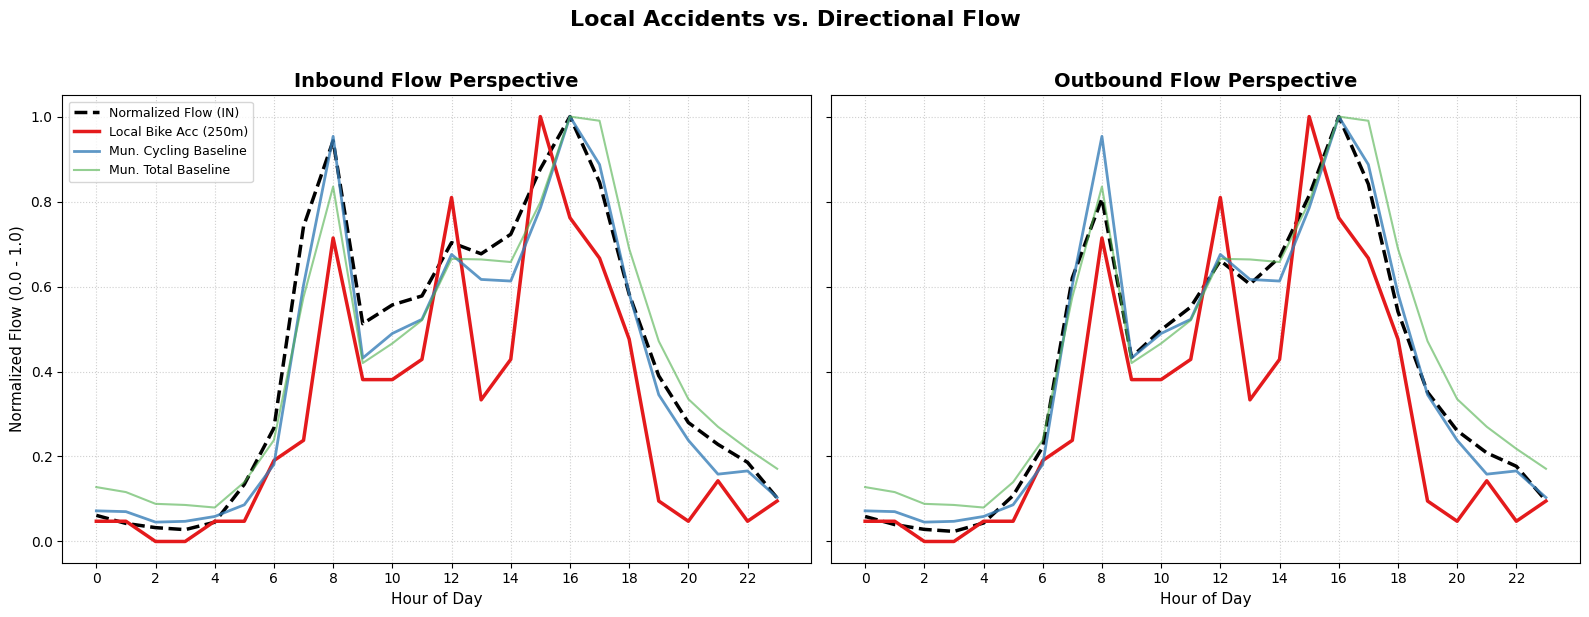

In [139]:
hourly_profile = (
    df_research_master
    .group_by("hour")
    .agg([
        pl.col("flow_in").mean().alias("avg_flow_in"),
        pl.col("flow_out").mean().alias("avg_flow_out"),
        pl.col("local_accidents").sum().alias("acc_local"),
        pl.col("total_cycling_accidents").sum().alias("acc_mun_cycling"),
        pl.col("total_accidents").sum().alias("acc_mun_overall")
    ])
    .sort("hour")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_configs = [
    ("Inbound Flow Perspective", "avg_flow_in"),
    ("Outbound Flow Perspective", "avg_flow_out")
]

for i, (title, flow_col) in enumerate(plot_configs):
    ax = axes[i]
    
    max_flow = hourly_profile[flow_col].max() or 1
    max_local = hourly_profile["acc_local"].max() or 1
    max_mun_bike = hourly_profile["acc_mun_cycling"].max() or 1
    max_mun_all = hourly_profile["acc_mun_overall"].max() or 1
    
    ax.plot(hourly_profile["hour"], hourly_profile[flow_col] / max_flow, 
            label=f"Normalized Flow ({flow_col.split('_')[-1].upper()})", 
            color="black", linewidth=2.5, linestyle="--")
    
    ax.plot(hourly_profile["hour"], hourly_profile["acc_local"] / max_local, 
            label="Local Bike Acc (250m)", color="#e41a1c", linewidth=2.5)
    
    ax.plot(hourly_profile["hour"], hourly_profile["acc_mun_cycling"] / max_mun_bike, 
            label="Mun. Cycling Baseline", color="#377eb8", linewidth=2, alpha=0.8)
    
    ax.plot(hourly_profile["hour"], hourly_profile["acc_mun_overall"] / max_mun_all, 
            label="Mun. Total Baseline", color="#4daf4a", linewidth=1.5, alpha=0.6)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Hour of Day", fontsize=11)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, linestyle=":", alpha=0.6)
    
    if i == 0:
        ax.set_ylabel("Normalized Flow (0.0 - 1.0)", fontsize=11)
        ax.legend(loc="upper left", frameon=True, fontsize=9)

plt.suptitle("Local Accidents vs. Directional Flow", fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('4.jpg', dpi=300, bbox_inches='tight')
plt.show()


From the figure below, we see that, while municipal baselines track normalized traffic flow throughout the day, localized sensor-captured accidents exhibit a more complex behavior. For instance, despite traffic peaking sharply at 8:00, localized accidents remain low, suggesting that morning commute risks are less severe or that sensors isolate a distinct accident profile.

Conversely, a prominent localized spike occurs at 12:00, likely driven by non-commuting traffic such as school runs or midday commercial activity. During the afternoon, localized accidents peak just before 16:00, aligning with the evening rush; since these paths function as inter-regional connectors, this correlation suggests that long-distance commuters might depart early to beat the traffic. Finally, localized accidents drop off sharply during the late evening and night compared to municipal baselines, as fewer cyclists cover inter-regional distances in the dark. However, even though traffic flow decreases, the number of accidents drops at the exact same pace. This means that, despite having fewer cyclists on the road, new hazards arise during these hours, such as poor street lighting

Clustering

In [512]:
df_true_accidents_and_baselines = (
    df_acc_fin
    .filter(pl.col("year") == 2024)
    .unique(subset=["gemeente", "year", "month", "hour"])
    .group_by(["gemeente", "year"])
    .agg([
        #  sensor proximity totals
        pl.col("local_accidents").sum().alias("total_local_acc"),
        
        #  municipality baseline totals
        pl.col("total_accidents").sum().alias("mun_total_overall"),
        pl.col("total_cycling_accidents").sum().alias("mun_total_cycling"),
        
        #  total counts from across the entire town
        pl.col("car_conflict").sum().alias("sum_car_conflicts"),
        pl.col("intersection").sum().alias("sum_intersections"),
        pl.col("school_peak").sum().alias("sum_school_peak"),
        pl.col("light").sum().alias("sum_dark"),
        pl.col("severity").sum().alias("sum_severity"),  
        pl.col("slick").sum().alias("sum_slick")  
    ])
)

df_town_context = (
    df_research_master
    .filter(pl.col("year") == 2024)
    .group_by(["gemeente", "year"])
    .agg([
        pl.col("total_pop").first().fill_null(5000).alias("total_pop"),
        pl.col("avg_income_per_capita").first().fill_null(22000).alias("avg_income"),
        pl.col("avg_employment_rate").first().fill_null(0.70).alias("employment_rate"),
        pl.col("relative_sensor_age").first().fill_null(1.0).alias("relative_sensor_age"),
        pl.col("pct_school_kids").first().alias("pct_school_kids"),
        pl.col("pct_young_profs").first().alias("pct_young_profs"),

        # Traffic Flow  Metrics
        pl.col("total_hourly_flow").std().alias("flow_std"),
        pl.col("total_hourly_flow").mean().alias("flow_mean"),
        pl.col("bad_weather_ratio").mean().fill_null(0.10).alias("bad_weather_ratio"),
        
        # Commuter Bias Profiles
        pl.col("inbound_push_ratio")
          .filter((pl.col("hour") >= 7) & (pl.col("hour") <= 9))
          .mean().fill_null(0.5).alias("am_push_bias"),
        pl.col("inbound_push_ratio")
          .filter((pl.col("hour") >= 14) & (pl.col("hour") <= 17))
          .mean().fill_null(0.5).alias("pm_push_bias")
    ])
)

df_final_clustering = (
    df_town_context 
    .join(df_true_accidents_and_baselines, on=["gemeente", "year"], how="left")
    .with_columns([
        pl.col("total_local_acc").fill_null(0),
        pl.col("sum_car_conflicts").fill_null(0),
        pl.col("sum_intersections").fill_null(0),
        pl.col("sum_school_peak").fill_null(0),
        pl.col("sum_dark").fill_null(0),
        pl.col("sum_slick").fill_null(0),        
        pl.col("mun_total_cycling").fill_null(0),
        pl.col("mun_total_overall").fill_null(0),
    ])
    .with_columns([
        (pl.col("sum_car_conflicts") / pl.col("mun_total_cycling")).fill_nan(0.0).alias("pct_car_conflicts"),
        (pl.col("sum_intersections") / pl.col("mun_total_cycling")).fill_nan(0.0).alias("pct_intersections"),
        (pl.col("sum_school_peak") / pl.col("mun_total_cycling")).fill_nan(0.0).alias("pct_school_peak"),
        (pl.col("sum_dark") / pl.col("mun_total_cycling")).fill_nan(0.0).alias("pct_dark"),
        (pl.col("sum_slick") / pl.col("mun_total_cycling")).fill_nan(0.0).alias("pct_slick"),
        
        (pl.col("flow_std") / pl.col("flow_mean")).fill_nan(0.0).alias("flow_volatility"),
        (pl.col("total_local_acc") / pl.col("mun_total_cycling")).fill_nan(0.0).alias("ratio_local_vs_total_cycling"),
        
        (pl.col("total_pop") * 0.71).alias("number_of_cyclists")
    ])
)

print(f"Rows for Clustering: {df_final_clustering.height}")

Rows for Clustering: 68


KMeans on Reduced Variables

In [513]:
all_features = [
    'total_pop', 'avg_income', 'employment_rate', 'relative_sensor_age', 
    'pct_school_kids', 'pct_young_profs', 'flow_std', 'flow_mean', 
    'bad_weather_ratio', 'am_push_bias', 'pm_push_bias', 'total_local_acc', 
    'mun_total_overall', 'mun_total_cycling', 'pct_car_conflicts', 'sum_severity',
    'pct_intersections', 'pct_school_peak', 'pct_dark', 'pct_slick', 
    'flow_volatility', 'ratio_local_vs_total_cycling','number_of_cyclists'
]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_final_clustering.select(all_features).to_pandas())

pca = PCA(n_components=3)
pca.fit(scaled_data)

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=all_features
)

loadings['total_influence'] = loadings.abs().sum(axis=1)
print(loadings.sort_values(by='total_influence', ascending=False).head(15))

                                   PC1       PC2       PC3  total_influence
flow_mean                     0.243781  0.366197  0.235555         0.845533
flow_std                      0.212560  0.410276  0.217883         0.840719
total_local_acc               0.217585  0.219259  0.342468         0.779312
pct_dark                      0.049806 -0.282403  0.368512         0.700721
pct_school_kids              -0.089563 -0.374385  0.172506         0.636453
sum_severity                  0.351014 -0.158940 -0.095871         0.605825
employment_rate               0.099389  0.148038 -0.336907         0.584334
ratio_local_vs_total_cycling  0.034742  0.154150  0.394616         0.583507
mun_total_overall             0.374368 -0.133438 -0.072316         0.580122
mun_total_cycling             0.380393 -0.106630 -0.053103         0.540126
total_pop                     0.377620 -0.119572 -0.042043         0.539235
number_of_cyclists            0.377620 -0.119572 -0.042043         0.539235
bad_weather_

<Figure size 1200x1000 with 0 Axes>

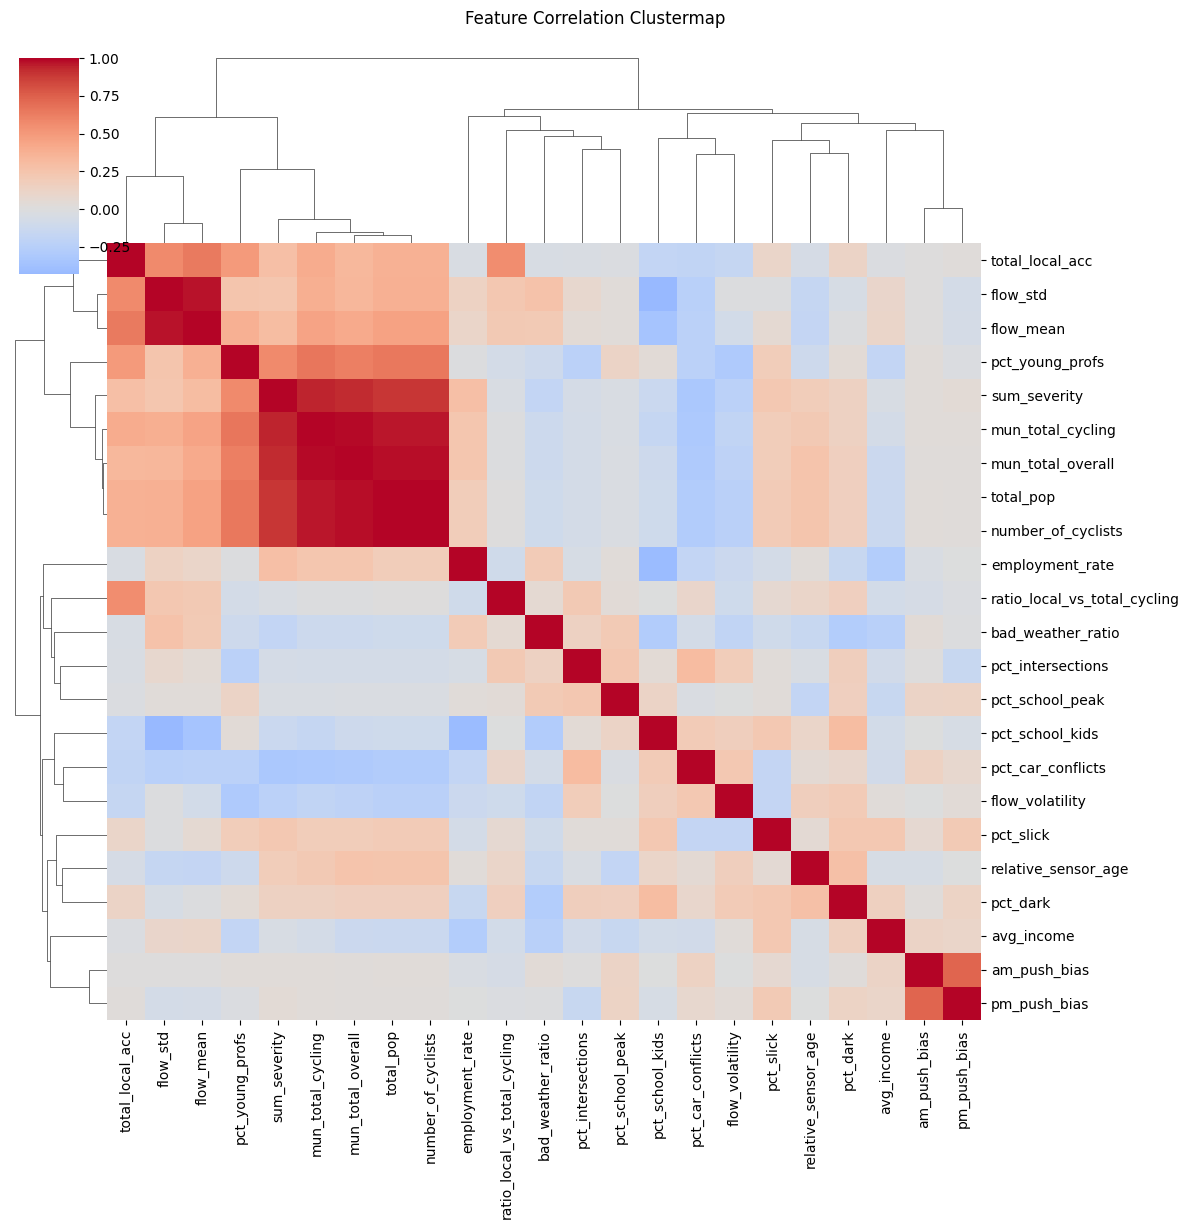

In [197]:
corr_matrix = df_final_clustering.select(all_features).to_pandas().corr()

plt.figure(figsize=(12, 10))
g = sns.clustermap(
    corr_matrix, 
    annot=False, 
    cmap='coolwarm', 
    center=0,
    figsize=(12, 12),
    dendrogram_ratio=(.1, .2)
)
g.fig.suptitle('Feature Correlation Clustermap', y=1.02)
plt.savefig('5.jpg', dpi=300, bbox_inches='tight')
plt.show()


we need to balance influence and redundancy to pick the most essential features for clustering

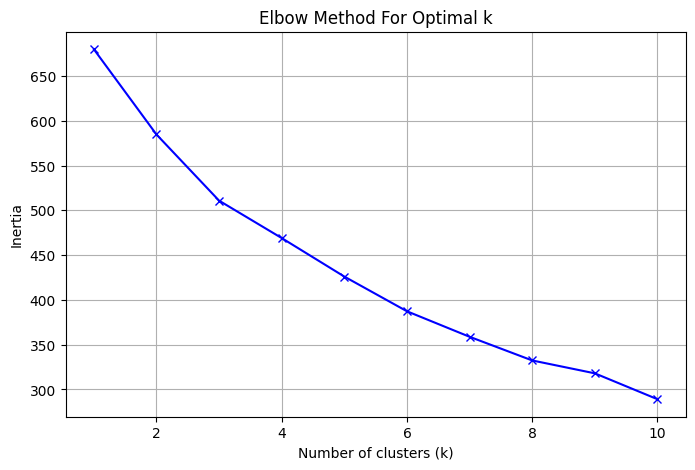

In [490]:
essential_features = [
    'mun_total_cycling', 'pct_school_kids', 'avg_income', 'pct_dark', 'pct_slick', 'am_push_bias',
    'flow_std', 'pct_intersections', 'pct_car_conflicts', 'bad_weather_ratio'
]


def plot_elbow_method(features, max_clusters=10):
    data = df_final_clustering.select(features).to_pandas()
    scaled_data = StandardScaler().fit_transform(data)
    
    inertia = []
    k_range = range(1, max_clusters + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=6, n_init=12)
        kmeans.fit(scaled_data)
        inertia.append(kmeans.inertia_)
        
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertia, 'bx-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method For Optimal k')
    plt.grid(True)
    plt.savefig('6.jpg', dpi=300, bbox_inches='tight')
    plt.show()

plot_elbow_method(essential_features)


No clear elbow but the fall of inertia seems to taper off by 4 so attempt with 4 and check logical accuracy

In [566]:
def run_cluster_model(features, n_clusters=4):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_final_clustering.select(features).to_pandas())
    model = KMeans(n_clusters=4, random_state=1, n_init=12)
    return model.fit_predict(scaled_data)

df_final_clustering = df_final_clustering.with_columns([
    pl.Series("cluster_essential", run_cluster_model(essential_features))
])

In [567]:
agg_logic = [
    pl.all().exclude(["cluster_id", "cluster_essential"]).mean(),
    pl.len().alias("n_municipalities")
]

essential_profiles = df_final_clustering.group_by("cluster_essential").agg(agg_logic).sort("cluster_essential")

print("Cluster Profiles")
essential_profiles

Cluster Profiles


cluster_essential,gemeente,year,total_pop,avg_income,employment_rate,relative_sensor_age,pct_school_kids,pct_young_profs,flow_std,flow_mean,bad_weather_ratio,am_push_bias,pm_push_bias,total_local_acc,mun_total_overall,mun_total_cycling,sum_car_conflicts,sum_intersections,sum_school_peak,sum_dark,sum_severity,sum_slick,pct_car_conflicts,pct_intersections,pct_school_peak,pct_dark,pct_slick,flow_volatility,ratio_local_vs_total_cycling,number_of_cyclists,n_municipalities
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32
0,null,2024.0,32009.26087,27460.713325,0.730107,2.391304,0.115063,0.167426,771.608857,919.838768,0.14909,0.629741,0.613427,0.608696,108.695652,39.608696,22.73913,14.347826,13.652174,6.913043,4.913043,12.391304,0.58174,0.371744,0.353736,0.159819,0.313013,0.841708,0.010851,22726.575217,23
1,null,2024.0,28800.625,23986.043207,0.734925,2.625,0.109899,0.168696,630.567806,612.982205,0.161684,0.29275,0.353933,0.4375,92.4375,27.9375,16.1875,11.5625,9.125,3.5625,2.6875,6.4375,0.644144,0.394668,0.334541,0.108752,0.196003,1.013452,0.013399,20448.44375,16
2,null,2024.0,105482.285714,25774.111034,0.746251,2.428571,0.095385,0.185876,4959.872452,5833.885417,0.172091,0.636843,0.580108,2.571429,440.142857,182.571429,98.857143,81.571429,64.428571,33.714286,14.142857,56.428571,0.564179,0.493898,0.355452,0.144874,0.264441,0.855526,0.022648,74892.422857,7
3,null,2024.0,27721.772727,25319.017525,0.724653,2.363636,0.115732,0.166312,663.301358,774.693782,0.157489,0.600246,0.55602,0.590909,80.181818,23.727273,17.954545,13.045455,7.909091,4.0,2.681818,6.681818,0.788773,0.567924,0.356911,0.172376,0.260125,0.919598,0.024718,19682.458636,22


Wealthy Suburbs (Cluster 0) - 23 muns
moderate pop (~32,000) with highest avg income and young sensors
high % school kids - high AM push and PM - school drop offs?
most slick road and many dark accidents - better infrastructure - maintenance?

Low-Activity Commuter Zones (Cluster 1) -  - 16 muns
small pop ~28,000 and lowest income and lowest cycling volume 
everyone seems to be leaving - lowest AM push  
lowest accidents but when they happen they are car conflicts and intersections -- however, relatively safe

Metropolitan Centers (Cluster 2) - 7 muns
massive pop ~105,000,  avg income, highest employment rate,  and highest % of people of working age with lowest % schoolkids
massive cycling volume, most number of bad weather days
big am push - people coming in for work and people seem to be leaving in the pm
most accidents captured 
accdients at intersections - school rush issues -- policy to help with this - to manage the high volume

Volatile Conflict Zones (Cluster 3) - 22 muns
moderate pop (~27,000) with 2nd lowest cycle traffic , avg income 
high AM push - high number of school kids ?
high flow volatility tho 
mostly car conflicts(highest %) at intersections here (highest%) -- danger


Cluster Mapping

In [591]:
coords_lookup = df_sites[['gemeente', 'lat', 'long']].copy()
coords_lookup['lat'] = coords_lookup['lat'].astype(float)
coords_lookup['long'] = coords_lookup['long'].astype(float)
coords_lookup = coords_lookup.groupby("gemeente").mean().reset_index()

df_map_source = df_final_clustering.to_pandas().merge(
    coords_lookup, 
    on="gemeente", 
    how="left"
)

flanders_map = folium.Map(location=[51.0, 4.47], zoom_start=9, tiles="CartoDB positron")

color_map = {
    0: 'green', 
    1: 'blue', 
    2: 'red', 
    3: 'orange'  
}

cluster_labels = {
    0: 'Wealthy Suburbs',
    1: 'Low-Activity Commuter Zones',
    2: 'Metropolitan Centers',    
    3: 'Volatile Conflict Zones'
}

feature_groups = {}
for cid, label in cluster_labels.items():
    layer_name = f"Cluster {cid}: {label}" 
    feature_groups[cid] = folium.FeatureGroup(name=layer_name)
    flanders_map.add_child(feature_groups[cid])

for _, row in df_map_source.iterrows():
    cid = int(row['cluster_essential'])
    town_name = str(row['gemeente']).title()
    
    popup_text = f"""
    <div style='font-family: sans-serif; min-width: 200px;'>
        <h4 style='margin:0; color:#333;'><b>{town_name}</b></h4>
        <p style='margin:5px 0; color:{color_map.get(cid, 'gray')}; font-weight:bold;'>{cluster_labels.get(cid, 'Other')}</p>
        <hr style='margin:5px 0;'>
        <b>Cycling Accidents:</b> {row['mun_total_cycling']:,.0f}<br>
        <b>% Car Conflicts %:</b> {row['pct_car_conflicts']*100:.1f}%<br>
        <b>Flow Volatility:</b> {row['flow_volatility']:.2f}<br>
        <b>% Intersection Risk:</b> {row['pct_intersections']*100:.1f}%<br>
        <b>Number of Cyclists:</b> {row['number_of_cyclists']:.2f}
    </div>
    """
    
    marker_radius = 15 if cid == 2 else 8
    
    folium.CircleMarker(
        location=[row['lat'], row['long']], 
        radius=marker_radius,
        popup=folium.Popup(popup_text, max_width=300),
        color='#444444',
        weight=1,
        fill=True,
        fill_color=color_map.get(cid, 'gray'),
        fill_opacity=0.85
    ).add_to(feature_groups[cid])

folium.LayerControl(collapsed=False).add_to(flanders_map)
flanders_map

In [575]:
df_cluster_mapping = df_final_clustering.select(["gemeente", "cluster_essential"])

df_research_master = df_research_master.join(
    df_cluster_mapping, 
    on="gemeente", 
    how="left"
)

df_research_master = df_research_master.with_columns(
    pl.col("cluster_essential").fill_null(-1) 
)
df_coords_lookup = (
    pl.from_pandas(df_map_source)
    .select(["gemeente", "lat", "long"])
    .unique(subset=["gemeente"])
)

df_research_master = (
    df_research_master
    .join(df_coords_lookup, on="gemeente", how="left")
)

In [576]:
df_research_master.write_csv('fin_clustering.csv')

Story Enhancement

aggregate at the yearly level and create the features needed for furthr analysis

In [577]:
df_research_master = df_research_master.with_columns(
    pl.when((pl.col("hour").is_between(7, 9)) | (pl.col("hour").is_between(15, 17)))
    .then(1)
    .otherwise(0)
    .alias("is_school_peak")
)
sum_cols = [
    "total_accidents",
    "total_cycling_accidents",
    "car_conflict",
    "severity",
    "slick",
    "light",
    "intersection",
    "school_peak",
    "local_accidents",
]

mean_cols = [
    "total_hourly_flow",
    "avg_temp",
    "avg_precip",
    "avg_mun_wind",
    "bad_weather_ratio",
    "relative_sensor_age",
    "avg_income_per_capita",
    "prof_earner_ratio",
    "avg_employment_rate",
    "inbound_push_ratio",
]


demo_cols = [col for col in df_research_master.columns if col.startswith("pct_") or col == "total_pop"]
df_yearly = df_research_master.filter((pl.col("year") >= 2021) & (pl.col("year") <= 2024)).group_by(["gemeente", "year"]).agg(
    [pl.col(c).sum() for c in sum_cols]
    + [pl.col(c).mean() for c in mean_cols]
    + [pl.col(c).mean() for c in demo_cols]
)
df_yearly = df_yearly.with_columns(
    [
        (pl.col("total_accidents") / pl.col("total_hourly_flow")).alias(
            "accident_rate_per_flow"
        ),
        (pl.col("total_accidents") / pl.col("total_pop")).alias(
            "accident_rate_per_capita"
        ),
        (pl.col("severity") / pl.col("total_accidents")).alias("severity_index"),
    ]
)

df_yearly.head()

gemeente,year,total_accidents,total_cycling_accidents,car_conflict,severity,slick,light,intersection,school_peak,local_accidents,total_hourly_flow,avg_temp,avg_precip,avg_mun_wind,bad_weather_ratio,relative_sensor_age,avg_income_per_capita,prof_earner_ratio,avg_employment_rate,inbound_push_ratio,total_pop,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,accident_rate_per_flow,accident_rate_per_capita,severity_index
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Lummen""",2024,34,9,4,3,3,1,7,4,0,204.142361,11.68517,0.116475,10.725891,0.155577,2.0,26802.853548,0.592619,0.730329,0.489916,15320.0,0.073368,0.10607,0.069909,0.163316,0.350849,0.236488,0.506005,0.493995,0.955809,0.044191,0.430809,0.428655,0.059204,0.081332,0.16655,0.002219,0.088235
"""Nijlen""",2024,50,15,9,4,3,1,5,2,0,767.486111,12.109204,0.118394,12.581581,0.150441,2.0,26788.691874,0.587973,0.724252,0.983981,23707.0,0.073312,0.112034,0.082592,0.159868,0.351668,0.220526,0.492639,0.507361,0.962965,0.037035,0.4594,0.399924,0.054372,0.086304,0.065148,0.002109,0.08
"""Gent""",2021,1220,494,296,40,161,103,230,138,1,743.822917,10.692369,0.096772,12.348918,0.145534,2.0,20963.865045,0.592106,0.744387,0.598162,263703.0,0.086184,0.104656,0.102828,0.243664,0.296887,0.165781,0.498603,0.501397,0.845068,0.154932,0.561272,0.306731,0.047982,0.084015,1.640175,0.004626,0.032787
"""Nazareth""",2024,44,9,5,0,2,0,2,3,0,76.246528,12.002278,0.100273,12.8688,0.136627,2.0,28697.054768,0.599836,0.751132,0.527573,12305.0,0.076392,0.103941,0.082812,0.161479,0.348964,0.226412,0.491995,0.508005,0.951889,0.048111,0.454531,0.39488,0.059163,0.091426,0.577075,0.003576,0.0
"""Heers""",2023,14,2,1,0,0,0,1,0,0,148.576389,11.899064,0.120213,11.951451,0.170349,1.0,23994.865567,0.59331,0.716611,0.516502,7554.0,0.074927,0.10511,0.074927,0.174345,0.354514,0.216177,0.498941,0.501059,0.949828,0.050172,0.445459,0.404024,0.059439,0.091078,0.094228,0.001853,0.0


In [578]:
df_features = df_yearly.sort(["gemeente", "year"]).with_columns(
    [
        pl.col("severity")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_severe_count"),
        pl.col("light")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_dark_count"),
        pl.col("local_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_local_accidents"),
        pl.col("school_peak")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_school_accidents"),
        pl.col("slick")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_slick_accidents"),
        pl.col("car_conflict")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_carconflict_accidents"),
        pl.col("intersection")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_int_accidents"),
        pl.col("total_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_total_accidents"),
        pl.col("total_cycling_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_total_cyc_accidents"),
        pl.col("total_cycling_accidents")
        .mean()
        .over("gemeente")
        .alias("historical_town_avg"),
    ]
)
features = [
    "total_hourly_flow",
    "avg_temp",
    "avg_precip",
    "avg_mun_wind",
    "avg_income_per_capita",
    "prof_earner_ratio",
    "avg_employment_rate",
    "total_pop",
    "pct_young_children",
    "pct_school_kids",
    "pct_uni_students",
    "pct_young_profs",
    "pct_senior_profs",
    "pct_seniors",
    "pct_male",
    "pct_belgian",
    "pct_single",
    "pct_married",
    "pct_widowed",
    "prev_year_severe_count",
    "prev_year_dark_count",
    "prev_year_total_accidents",
    "prev_year_school_accidents",
    "prev_year_slick_accidents",
    "prev_year_local_accidents",
    "prev_year_total_cyc_accidents",
    "historical_town_avg",
    "prev_year_carconflict_accidents",
    "prev_year_int_accidents",
    "school_zone_exposure",
    "risk_per_1k_residents",
    "flow_density",
    "bad_weather_ratio",
    "relative_sensor_age",
    "inbound_push_ratio",
]

df_features = df_features.with_columns(
    [
        (
            pl.col("pct_school_kids")
            * pl.col("total_pop")
            / pl.col("total_hourly_flow")
        ).alias("school_zone_exposure"),
        (pl.col("prev_year_total_accidents") / (pl.col("total_pop") / 1000)).alias(
            "risk_per_1k_residents"
        ),
        (pl.col("avg_mun_wind") * pl.col("avg_precip")).alias("weather_severity_index"),
        (pl.col("total_hourly_flow") / pl.col("total_pop")).alias("flow_density"),
    ]
)
df_features = df_features.sort(["gemeente", "year"]).with_columns(
    pl.col("total_cycling_accidents")
    .backward_fill()
    .over("gemeente")
    .alias("smoothed_target")
)
upper_limit = df_features["total_hourly_flow"].quantile(0.99)
df_features = df_features.with_columns(
    pl.col("total_hourly_flow").clip(upper_bound=upper_limit)
)
df_features = (
    df_features.with_columns(
        [
            pl.when(pl.col(col).is_infinite())
            .then(0.0)
            .otherwise(pl.col(col))
            .alias(col)
            for col in features
        ]
    )
    .fill_null(0.0)
    .with_columns([pl.col(col).cast(pl.Float32) for col in features])
)
df_features

gemeente,year,total_accidents,total_cycling_accidents,car_conflict,severity,slick,light,intersection,school_peak,local_accidents,total_hourly_flow,avg_temp,avg_precip,avg_mun_wind,bad_weather_ratio,relative_sensor_age,avg_income_per_capita,prof_earner_ratio,avg_employment_rate,inbound_push_ratio,total_pop,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,accident_rate_per_flow,accident_rate_per_capita,severity_index,prev_year_severe_count,prev_year_dark_count,prev_year_local_accidents,prev_year_school_accidents,prev_year_slick_accidents,prev_year_carconflict_accidents,prev_year_int_accidents,prev_year_total_accidents,prev_year_total_cyc_accidents,historical_town_avg,school_zone_exposure,risk_per_1k_residents,weather_severity_index,flow_density,smoothed_target
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f32,f64,f32,f32,f32,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f32,f64
"""Aalst""",2021.0,234.0,68.0,52.0,8.0,14.0,10.0,29.0,20.0,1.0,1318.430542,10.692369,0.096772,12.348918,0.145534,2.0,21372.589844,0.576508,0.744387,0.505033,87978.0,0.084942,0.11246,0.087204,0.177567,0.337994,0.199834,0.491475,0.508525,0.905806,0.094194,0.475005,0.362238,0.059981,0.102776,0.177484,0.00266,0.034188,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.75,7.504377,0.0,1.195035,0.014986,68.0
"""Aalst""",2022.0,326.0,109.0,82.0,15.0,15.0,11.0,50.0,39.0,0.0,1627.590332,11.986206,0.071809,12.145395,0.119915,3.0,22937.320312,0.590854,0.759204,0.515943,88854.0,0.083744,0.115425,0.08721,0.176447,0.335145,0.202028,0.490434,0.509566,0.902762,0.097238,0.481408,0.358048,0.05823,0.102314,0.200296,0.003669,0.046012,8.0,10.0,1.0,20.0,14.0,52.0,29.0,234.0,68.0,96.75,6.30134,2.633534,0.872147,0.018318,109.0
"""Aalst""",2023.0,254.0,105.0,79.0,9.0,25.0,17.0,49.0,37.0,0.0,1618.892334,12.159162,0.110651,14.147687,0.152623,4.0,24427.638672,0.591747,0.757155,0.519057,90068.0,0.082615,0.117689,0.086901,0.176544,0.333015,0.203235,0.490074,0.509926,0.895768,0.104232,0.48792,0.354577,0.056779,0.100724,0.156897,0.00282,0.035433,15.0,11.0,0.0,39.0,15.0,82.0,50.0,326.0,109.0,96.75,6.547687,3.619488,1.565457,0.017974,105.0
"""Aalst""",2024.0,303.0,105.0,70.0,7.0,31.0,26.0,33.0,38.0,1.0,1758.822876,12.002277,0.100273,12.868799,0.136627,5.0,25065.582031,0.595392,0.751132,0.50729,90995.0,0.082477,0.119204,0.086873,0.176944,0.330359,0.204143,0.490917,0.509083,0.89273,0.10727,0.492214,0.351426,0.056256,0.100104,0.172274,0.00333,0.023102,9.0,17.0,0.0,37.0,25.0,79.0,49.0,254.0,105.0,96.75,6.167193,2.791362,1.290387,0.019329,105.0
"""Aalter""",2022.0,51.0,19.0,14.0,3.0,4.0,4.0,4.0,7.0,0.0,494.081085,12.114546,0.099039,12.929831,0.174261,0.0,25044.525391,0.593789,0.759204,0.557531,29340.0,0.07287,0.108862,0.087355,0.162713,0.344649,0.223551,0.502113,0.497887,0.956237,0.043763,0.439434,0.417246,0.059032,0.084288,0.103222,0.001738,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.333332,6.464526,0.0,1.280558,0.01684,19.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zele""",2023.0,79.0,41.0,21.0,7.0,14.0,13.0,16.0,11.0,1.0,606.725708,12.159162,0.110651,14.147687,0.152623,1.0,23109.119141,0.580113,0.757155,0.75132,21374.0,0.083419,0.119538,0.093712,0.172686,0.332647,0.197998,0.497474,0.502526,0.898755,0.101245,0.453542,0.406007,0.05881,0.081641,0.130207,0.003696,0.088608,3.0,1.0,0.0,8.0,4.0,7.0,6.0,23.0,11.0,30.333334,4.211129,1.076074,1.565457,0.028386,41.0
"""Zele""",2024.0,90.0,39.0,23.0,7.0,12.0,4.0,16.0,11.0,2.0,604.111084,12.002277,0.100273,12.868799,0.136627,2.0,23839.064453,0.587866,0.751132,0.740315,21501.0,0.083252,0.117483,0.094693,0.172364,0.332357,0.199851,0.497884,0.502116,0.891307,0.108693,0.457514,0.400772,0.058881,0.082833,0.148979,0.004186,0.077778,7.0,13.0,1.0,11.0,14.0,21.0,16.0,79.

In [579]:
df_res=pl.read_csv('curated/final_results.csv')

pull the data with the predicted accidents for 2025 and do a deep dive

In [580]:
def unify_schema(df):
    return df.with_columns([
        cs.numeric().exclude("severity_index").cast(pl.Float64),
        pl.col("severity_index").cast(pl.Float64)
    ])

df_features_clean = unify_schema(df_features)
df_2025_clean = unify_schema(df_res)

df_master = pl.concat([df_features_clean, df_2025_clean], how="diagonal")

predictive_cols = ["predicted_num_accidents", "risk_rank", "weather_severity_index"]
cols_to_fill = [c for c in predictive_cols if c in df_master.columns]
df_master = df_master.with_columns([
    pl.col(c).fill_null(0.0) for c in cols_to_fill
])

df_master = df_master.with_columns(
    pl.when(pl.col("year") == 2025)
    .then(pl.col("predicted_num_accidents"))
    .otherwise(pl.col("total_cycling_accidents"))
    .alias("total_cycling_accidents_analysis")
)
df_master.filter(pl.col("gemeente") == "Gent")

gemeente,year,total_accidents,total_cycling_accidents,car_conflict,severity,slick,light,intersection,school_peak,local_accidents,total_hourly_flow,avg_temp,avg_precip,avg_mun_wind,bad_weather_ratio,relative_sensor_age,avg_income_per_capita,prof_earner_ratio,avg_employment_rate,inbound_push_ratio,total_pop,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,accident_rate_per_flow,accident_rate_per_capita,severity_index,prev_year_severe_count,prev_year_dark_count,prev_year_local_accidents,prev_year_school_accidents,prev_year_slick_accidents,prev_year_carconflict_accidents,prev_year_int_accidents,prev_year_total_accidents,prev_year_total_cyc_accidents,historical_town_avg,school_zone_exposure,risk_per_1k_residents,weather_severity_index,flow_density,smoothed_target,predicted_num_accidents,pred_per_1k_residents,risk_rank,most_frequent_type,total_cycling_accidents_analysis
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64
"""Gent""",2021.0,1220.0,494.0,296.0,40.0,161.0,103.0,230.0,138.0,1.0,743.822937,10.692369,0.096772,12.348918,0.145534,2.0,20963.865234,0.592106,0.744387,0.598162,263703.0,0.086184,0.104656,0.102828,0.243664,0.296887,0.165781,0.498603,0.501397,0.845068,0.154932,0.561272,0.306731,0.047982,0.084015,1.640175,0.004626,0.032787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,553.5,37.102917,0.0,1.195035,0.002821,494.0,0.0,null,0.0,null,494.0
"""Gent""",2022.0,1353.0,632.0,337.0,48.0,180.0,161.0,283.0,205.0,4.0,1524.315918,11.961095,0.072754,12.149916,0.120862,3.0,22384.0,0.607175,0.759204,0.660588,265086.0,0.085648,0.105139,0.103642,0.242876,0.296824,0.165871,0.498687,0.501313,0.839803,0.160197,0.568038,0.302223,0.0468,0.082939,0.887611,0.005104,0.035477,40.0,103.0,1.0,138.0,161.0,296.0,230.0,1220.0,494.0,553.5,18.284267,4.60228,0.883954,0.00575,632.0,0.0,null,0.0,null,632.0
"""Gent""",2023.0,1262.0,538.0,328.0,49.0,173.0,132.0,247.0,175.0,3.0,3130.590332,12.15982,0.110456,14.147141,0.152177,4.0,24043.314453,0.61448,0.757155,0.77014,268122.0,0.083238,0.10543,0.106306,0.243945,0.295798,0.165283,0.49884,0.50116,0.828556,0.171444,0.575495,0.298211,0.044901,0.081392,0.403119,0.004707,0.038827,48.0,161.0,4.0,205.0,180.0,337.0,283.0,1353.0,632.0,553.5,9.029607,5.04621,1.562638,0.011676,538.0,0.0,null,0.0,null,538.0
"""Gent""",2024.0,1280.0,550.0,277.0,50.0,193.0,132.0,230.0,191.0,2.0,2759.934082,12.002553,0.100262,12.870114,0.136619,5.0,24714.099609,0.619169,0.751132,0.72911,269597.0,0.081436,0.105224,0.10706,0.244765,0.29556,0.165955,0.49821,0.50179,0.82627,0.17373,0.579676,0.295986,0.043543,0.080795,0.463779,0.004748,0.0390625,49.0,132.0,3.0,175.0,173.0,328.0,247.0,1262.0,538.0,553.5,10.278506,4.681061,1.290379,0.010237,550.0,0.0,null,0.0,null,550.0
"""Gent""",2025.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4454.4824,12.230687,0.050635,11.941783,0.0868997,3.0,25795.209,0.626307,0.742867,0.767764,272657.0,0.079899,0.104582,0.108184,0.247083,0.293944,0.166308,0.498098,0.501902,0.822099,0.177901,0.5843789,0.2931852,0.04231,0.080126,0.0,0.0,null,50.0,132.0,2.0,191.0,193.0,277.0,230.0,1280.0,550.0,442.8,6.401417,4.694543,0.604669,0.016337,0.0,437.0,1.602746,1.0,"""slick""",437.0


Use PCA to figure out which features outside of historical accident trends are important

In [581]:
all_features = [
    'total_hourly_flow', 'avg_temp', 'avg_precip', 'avg_mun_wind', 'bad_weather_ratio', 'relative_sensor_age','pct_school_kids','pct_uni_students',
    'avg_income_per_capita', 'prof_earner_ratio', 'avg_employment_rate', 'inbound_push_ratio', 'total_pop','pct_young_children','pct_young_profs',
    'pct_seniors', 'pct_senior_profs', 'pct_male', 'pct_female', 'pct_belgian','pct_foreign', 'pct_single','pct_married',
    'pct_widowed', 'pct_divorced', 'school_zone_exposure', 'weather_severity_index',
    'flow_density']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_master.select(all_features).to_pandas())

pca = PCA(n_components=3)
pca.fit(scaled_data)

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=all_features
)

loadings['total_influence'] = loadings.abs().sum(axis=1)
print(loadings.sort_values(by='total_influence', ascending=False).head(20))

                             PC1       PC2       PC3  total_influence
weather_severity_index  0.057327 -0.215562  0.481917         0.754806
bad_weather_ratio       0.071041 -0.208772  0.473081         0.752894
avg_precip              0.044514 -0.138842  0.496143         0.679499
pct_married             0.201096  0.344841  0.125107         0.671044
pct_divorced            0.247755 -0.205682 -0.182710         0.636147
pct_senior_profs        0.164204  0.352890  0.084617         0.601711
total_pop              -0.119506 -0.293910 -0.146467         0.559883
prof_earner_ratio       0.264963 -0.184348 -0.096889         0.546200
pct_school_kids        -0.265261  0.137599  0.125742         0.528602
pct_seniors             0.328252 -0.080941 -0.115312         0.524504
pct_single             -0.318221 -0.178536 -0.021417         0.518173
total_hourly_flow       0.028294 -0.325972 -0.162404         0.516670
avg_mun_wind            0.063119 -0.325614  0.126379         0.515112
pct_widowed         

based on this list, split the important features into int and external risks - which are based on muncipality and those which may indicate things for a group of municipalities / inter-municipality travel like inbound push

In [582]:
def calculate_weighted_risk(df, alpha=0.75):
    internal_cols = [
        "pct_school_kids", "prof_earner_ratio", "avg_employment_rate", "pct_senior_profs", "pct_single",
        "total_pop", "total_hourly_flow", "pct_uni_students","pct_married","pct_male"
    ]
    external_cols = [
        "bad_weather_ratio", "inbound_push_ratio", "avg_temp", "avg_precip","avg_mun_wind","weather_severity_index"
    ]
    
    z_exprs = [
        ((pl.col(c) - pl.col(c).mean()) / pl.col(c).std()).alias(f"z_{c}")
        for c in internal_cols + external_cols
    ]
    
    df_scores = df_master.with_columns(z_exprs)
    
    df_scores = df_scores.with_columns([
        pl.mean_horizontal([f"z_{c}" for c in internal_cols]).alias("z_internal"),
        pl.mean_horizontal([f"z_{c}" for c in external_cols]).alias("z_external")
    ])
    
    df_scores = df_scores.with_columns(
        (alpha * pl.col("z_internal") + (1 - alpha) * pl.col("z_external")).alias("weighted_risk")
    )
    
    return df_scores

df_scored = calculate_weighted_risk(df_master)
df_map_scored = df_scored.to_pandas().merge(
    coords_lookup, 
    on="gemeente", 
    how="left"
)
df_clean = df_map_scored[df_map_scored["weighted_risk"].notnull()]

correlation = df_clean['weighted_risk'].corr(df_clean['total_cycling_accidents_analysis'])
print(f"Correlation between Weighted Risk and Accident Counts: {correlation:.3f}")

Correlation between Weighted Risk and Accident Counts: 0.451


since the weighted risk has a decent corr with accidents, use it to rank the muncipalities and see which ones are getting worse and which better over the years

In [583]:
df_delta = df_clean.groupby("gemeente").agg(
    risk_start=("weighted_risk", lambda x: x.sort_index().iloc[0]), 
    risk_end=("weighted_risk", lambda x: x.sort_index().iloc[-1]),
    start_year=("year", "min"),
    end_year=("year", "max")
)


df_delta['delta'] = df_delta['risk_end'] - df_delta['risk_start']

most_improved = df_delta.sort_values(by='delta').head(5)
most_worsening = df_delta.sort_values(by='delta', ascending=False).head(5)

if 'gemeente' not in most_improved.columns:
    most_improved = most_improved.reset_index()
if 'gemeente' not in most_worsening.columns:
    most_worsening = most_worsening.reset_index()

cluster_mapping = df_final_clustering[['gemeente', 'cluster_essential']].to_pandas()

improved_with_clusters = most_improved.merge(cluster_mapping, on='gemeente', how='left')
worsening_with_clusters = most_worsening.merge(cluster_mapping, on='gemeente', how='left')

In [584]:

print("--- Top 5 Improving ---")
print(improved_with_clusters[['gemeente', 'delta', 'cluster_essential']])

print("\n--- Top 5 Worsening ---")
print(worsening_with_clusters[['gemeente', 'delta', 'cluster_essential']])

--- Top 5 Improving ---
               gemeente     delta  cluster_essential
0                Aalter -0.338306                  0
1  Houthalen-Helchteren -0.300000                  1
2                 Lille -0.268033                  3
3           Dendermonde -0.266245                  0
4               Beveren -0.254115                  0

--- Top 5 Worsening ---
   gemeente     delta  cluster_essential
0  Kortrijk  0.873253                  2
1    Brugge  0.629725                  2
2  Kraainem  0.593082                  3
3  Zaventem  0.531986                  3
4    Tienen  0.526680                  3


Since we have identified those, see if they have any socioeconomic variations - pick from diff clusters to see effect

In [585]:
cluster_data = df_final_clustering.select(["gemeente", "cluster_essential"])
focus_cities = ["Kortrijk","Kraainem","Lille","Aalter"]
deep_dive_data = df_master.select([
    "gemeente", "year", "total_cycling_accidents_analysis", "severity", 
    "local_accidents", "bad_weather_ratio", "avg_income_per_capita", "avg_precip","avg_employment_rate",
    "relative_sensor_age", "inbound_push_ratio", "risk_per_1k_residents", "prof_earner_ratio",
    "pct_uni_students", "pct_school_kids", "pct_belgian","avg_mun_wind","total_hourly_flow"
]).join(
    cluster_data, on="gemeente", how="left"
).filter(
    pl.col("gemeente").is_in(focus_cities)
).sort(["gemeente", "year"]) 

df_plot = deep_dive_data.filter(pl.col("gemeente").is_in(focus_cities))

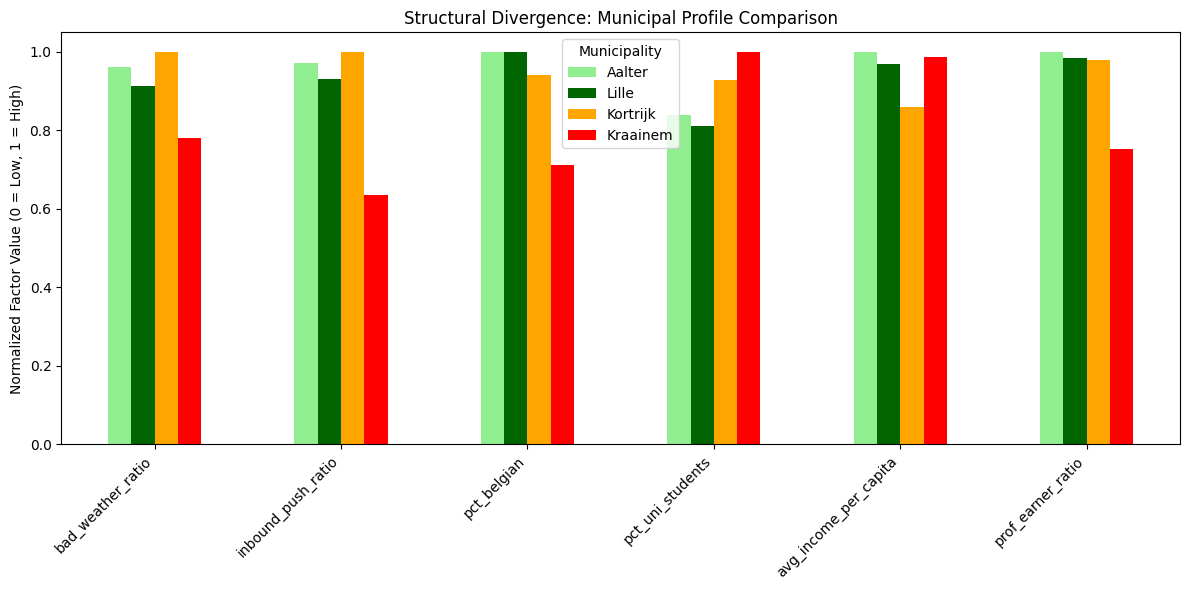

In [586]:
color_mapping = {
    "Aalter" : 'lightgreen',
    "Lille" : "darkgreen",
    'Kortrijk': 'orange',
    'Kraainem': 'red'
}

df_comp = df_plot.filter(pl.col("gemeente").is_in(["Kortrijk","Kraainem","Lille","Aalter"])).to_pandas()
diff_profile = df_comp.groupby("gemeente")[["bad_weather_ratio", "inbound_push_ratio","pct_belgian", "pct_uni_students", "avg_income_per_capita",'prof_earner_ratio']].mean()
normalized_profile = diff_profile / diff_profile.max()

desired_order = list(color_mapping.keys())
ordered_profile = normalized_profile.reindex([m for m in desired_order if m in normalized_profile.index])
colors = [color_mapping.get(col, 'gray') for col in ordered_profile.T.columns]

ax = ordered_profile.T.plot(kind='bar', figsize=(12, 6), color=colors)

plt.title("Structural Divergence: Municipal Profile Comparison")
plt.ylabel("Normalized Factor Value (0 = Low, 1 = High)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Municipality")
plt.tight_layout()
plt.savefig('7.jpg', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
more % of belgians in the towns doing better - better cycling etiquette maybe?
worst performing Kortrijk seems to have bad weather but overall that does not seem to change things as much
% uni students is higher in the places perfoming worse - probably shows congestion on tracks due to larger number of commuters casuing risk?
places doing better also seem to have higher avg income + prof earning ratio --> better infrastructure maybe?

See how the clusters are split when it comes to risk profiles

--- 2025 Normalized Cluster-Risk Distribution with Sample Size ---
risk_quantile        Low  Med-Low  Med-High   High   N
cluster_essential                                     
0                  0.217    0.348     0.217  0.217  23
1                  0.500    0.250     0.188  0.062  16
2                  0.143    0.000     0.000  0.857   7
3                  0.136    0.227     0.409  0.227  22


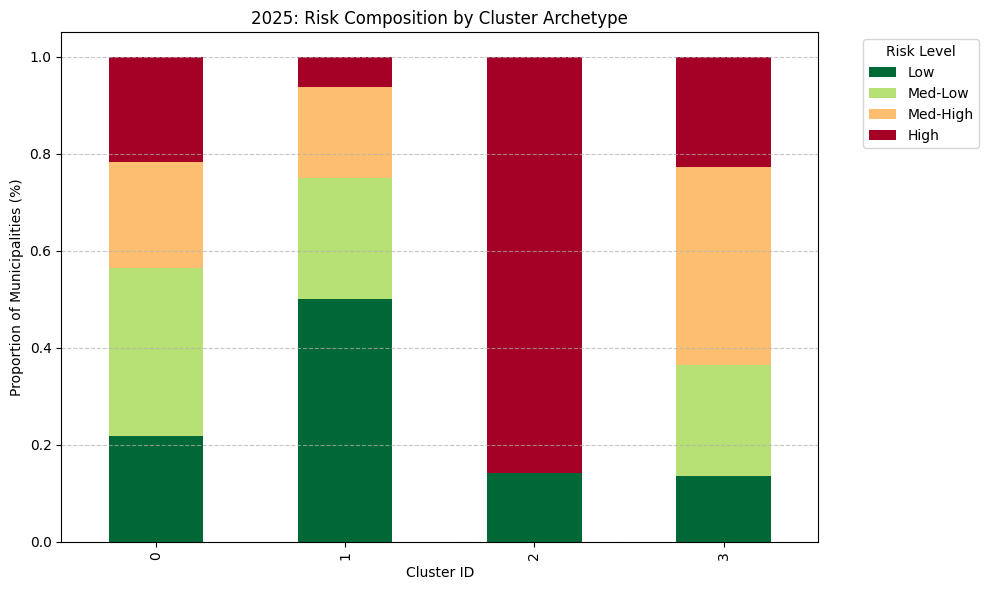

In [587]:
df_2025_scored = df_scored.filter(pl.col("year") == 2025).to_pandas()
df_2025_scored = df_2025_scored.merge(cluster_mapping, on='gemeente', how='left')

df_2025_scored['risk_quantile'] = pd.qcut(
    df_2025_scored['weighted_risk'], 
    q=4, 
    labels=['Low', 'Med-Low', 'Med-High', 'High']
)


cluster_risk_dist_2025 = pd.crosstab(
    df_2025_scored['cluster_essential'], 
    df_2025_scored['risk_quantile'], 
    normalize='index'
)

cluster_counts = df_2025_scored['cluster_essential'].value_counts().sort_index()

report_table = cluster_risk_dist_2025.copy()
report_table['N'] = cluster_counts

print("--- 2025 Normalized Cluster-Risk Distribution with Sample Size ---")
print(report_table.round(3))

ax = cluster_risk_dist_2025.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    colormap='RdYlGn_r'
)

plt.title("2025: Risk Composition by Cluster Archetype")
plt.ylabel("Proportion of Municipalities (%)")
plt.xlabel("Cluster ID")
plt.legend(title="Risk Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('8.jpg', dpi=300, bbox_inches='tight')
plt.show()


Cluster 2 - larger cities seem to have become more dangerous in 2025 whereas the low-activity zones have stayed relatively safer
Between cluster 0 and 3 - 3 (volatile zones) seem to be moving towards risk zones whereas the wealthier suburbs stay rooted

In [589]:
target_gemeentes =  ["Kortrijk","Kraainem","Aalter","Lille"]

df_combined = df_scored.join(df_final_clustering.select(["gemeente", "cluster_essential"]), 
                             on="gemeente", how="left")
df_pd = df_combined.to_pandas().fillna(0)

df_pd = df_pd[df_pd['gemeente'].isin(target_gemeentes)]

first_years = df_pd.groupby('gemeente')['year'].transform('min')
df_pd['is_first_year'] = df_pd['year'] == first_years
baseline_values = df_pd[df_pd['is_first_year']][['gemeente', 'weighted_risk']].rename(columns={'weighted_risk': 'baseline_risk'})
df_pd = df_pd.merge(baseline_values, on='gemeente', how='left')
df_pd['delta'] = df_pd['weighted_risk'] - df_pd['baseline_risk']
df_pd = df_pd.merge(coords_lookup, on="gemeente", how="left")

flanders_map = folium.Map(location=[51.0, 4.47], zoom_start=9, tiles="CartoDB positron")
risk_colormap = cm.LinearColormap(['green', 'yellow', 'red'], 
                                  vmin=df_pd['weighted_risk'].min(), 
                                  vmax=df_pd['weighted_risk'].max())

years = sorted(df_pd['year'].unique())

for year in years:
    for city in target_gemeentes:
        subset = df_pd[(df_pd['year'] == year) & (df_pd['gemeente'] == city)]
        if subset.empty:
            continue
            
        layer_name = f"Year {int(year)} | {city}"
        fg = folium.FeatureGroup(name=layer_name, show=False)
        flanders_map.add_child(fg)
        
        for _, row in subset.iterrows():
            fill_col = risk_colormap(row['weighted_risk'])
            radius = 8 + (row['weighted_risk'] * 2) if row['is_first_year'] else 8 + (row['delta'] * 15)
            
            popup_text = f"<b>{row['gemeente'].title()}</b><br>Year: {int(row['year'])}<br>Risk: {row['weighted_risk']:.2f}"
            
            folium.CircleMarker(
                location=[row['lat'], row['long']],
                radius=max(3, radius),
                popup=popup_text,
                fill=True, fill_color=fill_col,
                color='black', weight=0.5, fill_opacity=0.8
            ).add_to(fg)

folium.LayerControl(collapsed=False).add_to(flanders_map)
risk_colormap.add_to(flanders_map)
flanders_map

In [ ]:
can see how risk has ballooned over the years

In [592]:


cluster_labels = {
    0: 'Wealthy Suburbs',
    1: 'Low-Activity Commuter Zones',
    2: 'Metropolitan Centers',    
    3: 'Volatile Conflict Zones'
}

df_combined = df_scored.join(df_final_clustering.select(["gemeente", "cluster_essential"]), 
                             on="gemeente", how="left")
df_pd = df_combined.to_pandas().fillna(0)
first_years = df_pd.groupby('gemeente')['year'].transform('min')
df_pd['is_first_year'] = df_pd['year'] == first_years
baseline_values = df_pd[df_pd['is_first_year']][['gemeente', 'weighted_risk']].rename(columns={'weighted_risk': 'baseline_risk'})
df_pd = df_pd.merge(baseline_values, on='gemeente', how='left')
df_pd['delta'] = df_pd['weighted_risk'] - df_pd['baseline_risk']
df_pd = df_pd.merge(coords_lookup, on="gemeente", how="left")

flanders_map = folium.Map(location=[51.0, 4.47], zoom_start=9, tiles="CartoDB positron")
risk_colormap = cm.LinearColormap(['green', 'yellow', 'red'], 
                                  vmin=df_pd['weighted_risk'].min(), 
                                  vmax=df_pd['weighted_risk'].max())

years = sorted(df_pd['year'].unique())
clusters = sorted(df_pd['cluster_essential'].dropna().unique())

for year in years:
    for cid in clusters:
        label = cluster_labels.get(cid, f"Cluster {int(cid)}")
        layer_name = f"Year {int(year)} | {label}"
        
        fg = folium.FeatureGroup(name=layer_name, show=False)
        flanders_map.add_child(fg)
        
        subset = df_pd[(df_pd['year'] == year) & (df_pd['cluster_essential'] == cid)]
        
        for _, row in subset.iterrows():
            fill_col = risk_colormap(row['weighted_risk'])
            
            if row['is_first_year']:
                radius = 8 + (row['weighted_risk'] * 2)
                popup_text = f"""<b>{row['gemeente'].title()}</b><br>
                                 Type: {label}<br>
                                 Initial Risk: {row['weighted_risk']:.2f}<br>
                                 Accidents: {row['total_cycling_accidents_analysis']:.2f}"""
            else:
                radius = 8 + (row['delta'] * 15)
                popup_text = f"""<b>{row['gemeente'].title()}</b><br>
                                 Type: {label}<br>
                                 Year: {int(row['year'])}<br>
                                 Risk: {row['weighted_risk']:.2f}<br>
                                 Delta: {row['delta']:.2f}<br>
                                 Accidents: {row['total_cycling_accidents_analysis']:.2f}"""
            
            folium.CircleMarker(
                location=[row['lat'], row['long']],
                radius=max(3, radius),
                popup=popup_text,
                fill=True, fill_color=fill_col,
                color='black', weight=0.5, fill_opacity=0.8
            ).add_to(fg)

folium.LayerControl(collapsed=False).add_to(flanders_map)
risk_colormap.add_to(flanders_map)
flanders_map

connecting these to the clusters we can see that the low-activity zones seem to have added the least risk over the years whereas the larger towns and conflict zones seem to have grown riskier as the years pass
could be due to these areas facing more accidents due to infrastructure risk rather thn the other clusters where the issues are more sporadic